In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import gsw
import numpy as np
from mpl_toolkits.basemap import Basemap
import plotly.graph_objs as go
from collections import defaultdict

In [2]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]

# Projection: Latitude-Longitude projection

In [3]:
def profileNo_vs_latlon_bins(
    df: pd.DataFrame,
    lat_step: float,
    lon_step: float,
    show_threshold: bool = False,
    threshold_quantile: float = 0.95
) -> None:
    
    # === Identical bin construction to sample_cap_bins / plot_heatmap_npts ===
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 55, 90

    lon_bins = np.arange(lon_min, lon_max + lon_step, lon_step)

    sin_step = np.sin(np.radians(lat_step)) - np.sin(np.radians(0))
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.arange(sin_min, sin_max + sin_step, sin_step)
    lat_bins = np.degrees(np.arcsin(np.clip(sin_bins, -1, 1)))

    n_lon_bins = len(lon_bins) - 1
    n_lat_bins = len(lat_bins) - 1
    # =========================================================================

    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values

    lon_idx = np.clip(np.digitize(lon_vals, lon_bins) - 1, 0, n_lon_bins - 1)
    lat_idx = np.clip(np.digitize(lat_vals, lat_bins) - 1, 0, n_lat_bins - 1)

    # Count per bin
    from collections import defaultdict
    bin_counts = defaultdict(int)
    for i in range(len(lon_vals)):
        bin_counts[(lon_idx[i], lat_idx[i])] += 1

    g_len = list(bin_counts.values())
    g_len_sorted = sorted(g_len)

    # Threshold detection
    transition_point = None
    if len(g_len_sorted) > 1:
        g_len_diff = np.diff(g_len_sorted)
        threshold = np.quantile(g_len_diff, threshold_quantile)
        for i in range(1, len(g_len_sorted)):
            if g_len_sorted[i] - g_len_sorted[i - 1] > threshold:
                transition_point = i - 1
                break

    trace = go.Scatter(
        x=list(range(len(g_len_sorted))),
        y=g_len_sorted
    )

    if show_threshold and transition_point is not None:
        red_dot = go.Scatter(
            x=[transition_point],
            y=[g_len_sorted[transition_point]],
            mode='markers',
            marker=dict(color='red', size=10)
        )
        fig_data = [trace, red_dot]
    else:
        fig_data = [trace]

    layout = go.Layout(
        xaxis=dict(title='Bin No.'),
        yaxis=dict(title='Number of points per bin')
    )
    fig = go.Figure(data=fig_data, layout=layout)
    fig.show()

In [4]:
profileNo_vs_latlon_bins(df_ST, lat_step=5, lon_step=5, show_threshold=True, threshold_quantile=0.95)

In [5]:
profileNo_vs_latlon_bins(df_ST, lat_step=5, lon_step=5, show_threshold=True, threshold_quantile=0.99)

In [6]:
def plot_heatmap_npts(ds_cleaned, lon_step=5, lat_step=5):
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 55, 90
    resolution = 'l'

    # Longitude bins: uniform steps in degrees
    lon_bins = np.arange(lon_min, lon_max + lon_step, lon_step)

    # Equal-area latitude bins: uniform steps in sin(latitude)
    # Convert lat_step in degrees to an equivalent step in sin-space
    sin_step = np.sin(np.radians(lat_step)) - np.sin(np.radians(0))
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.arange(sin_min, sin_max + sin_step, sin_step)
    lat_bins = np.degrees(np.arcsin(np.clip(sin_bins, -1, 1)))

    n_lon_bins = len(lon_bins) - 1
    n_lat_bins = len(lat_bins) - 1

    lon_vals = ds_cleaned['Longitude_[deg_E]'].values
    lat_vals = ds_cleaned['Latitude_[deg_N]'].values

    lon_idx = np.clip(np.digitize(lon_vals, lon_bins) - 1, 0, n_lon_bins - 1)
    lat_idx = np.clip(np.digitize(lat_vals, lat_bins) - 1, 0, n_lat_bins - 1)

    count = np.zeros((n_lon_bins, n_lat_bins), dtype=int)
    for i in range(len(lon_vals)):
        count[lon_idx[i], lat_idx[i]] += 1

    fig = plt.figure(figsize=(8, 8), dpi=300)
    m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution=resolution)
    m.drawcoastlines()
    m.fillcontinents(color='grey', lake_color='lightblue')

    for lat in lat_bins:
        lons = np.linspace(lon_min, lon_max, 500)
        x, y = m(lons, np.full_like(lons, lat))
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    for lon in lon_bins:
        lats = np.linspace(lat_min, lat_max, 500)
        x, y = m(np.full_like(lats, lon), lats)
        m.plot(x, y, color='grey', linewidth=0.05, zorder=3)

    X, Y = np.meshgrid(lon_bins, lat_bins)
    X_map, Y_map = m(X, Y)
    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)
    m.pcolormesh(X_map, Y_map, count.T, cmap=cmap, vmin=1, vmax=None)

    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='lightblue')
    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Number of points in bin')
    plt.xticks([])
    plt.yticks([])
    plt.title(f'Number of Points per Bin ({lon_step}° lon x ~{lat_step}° lat equal-area bins)')
    plt.show()

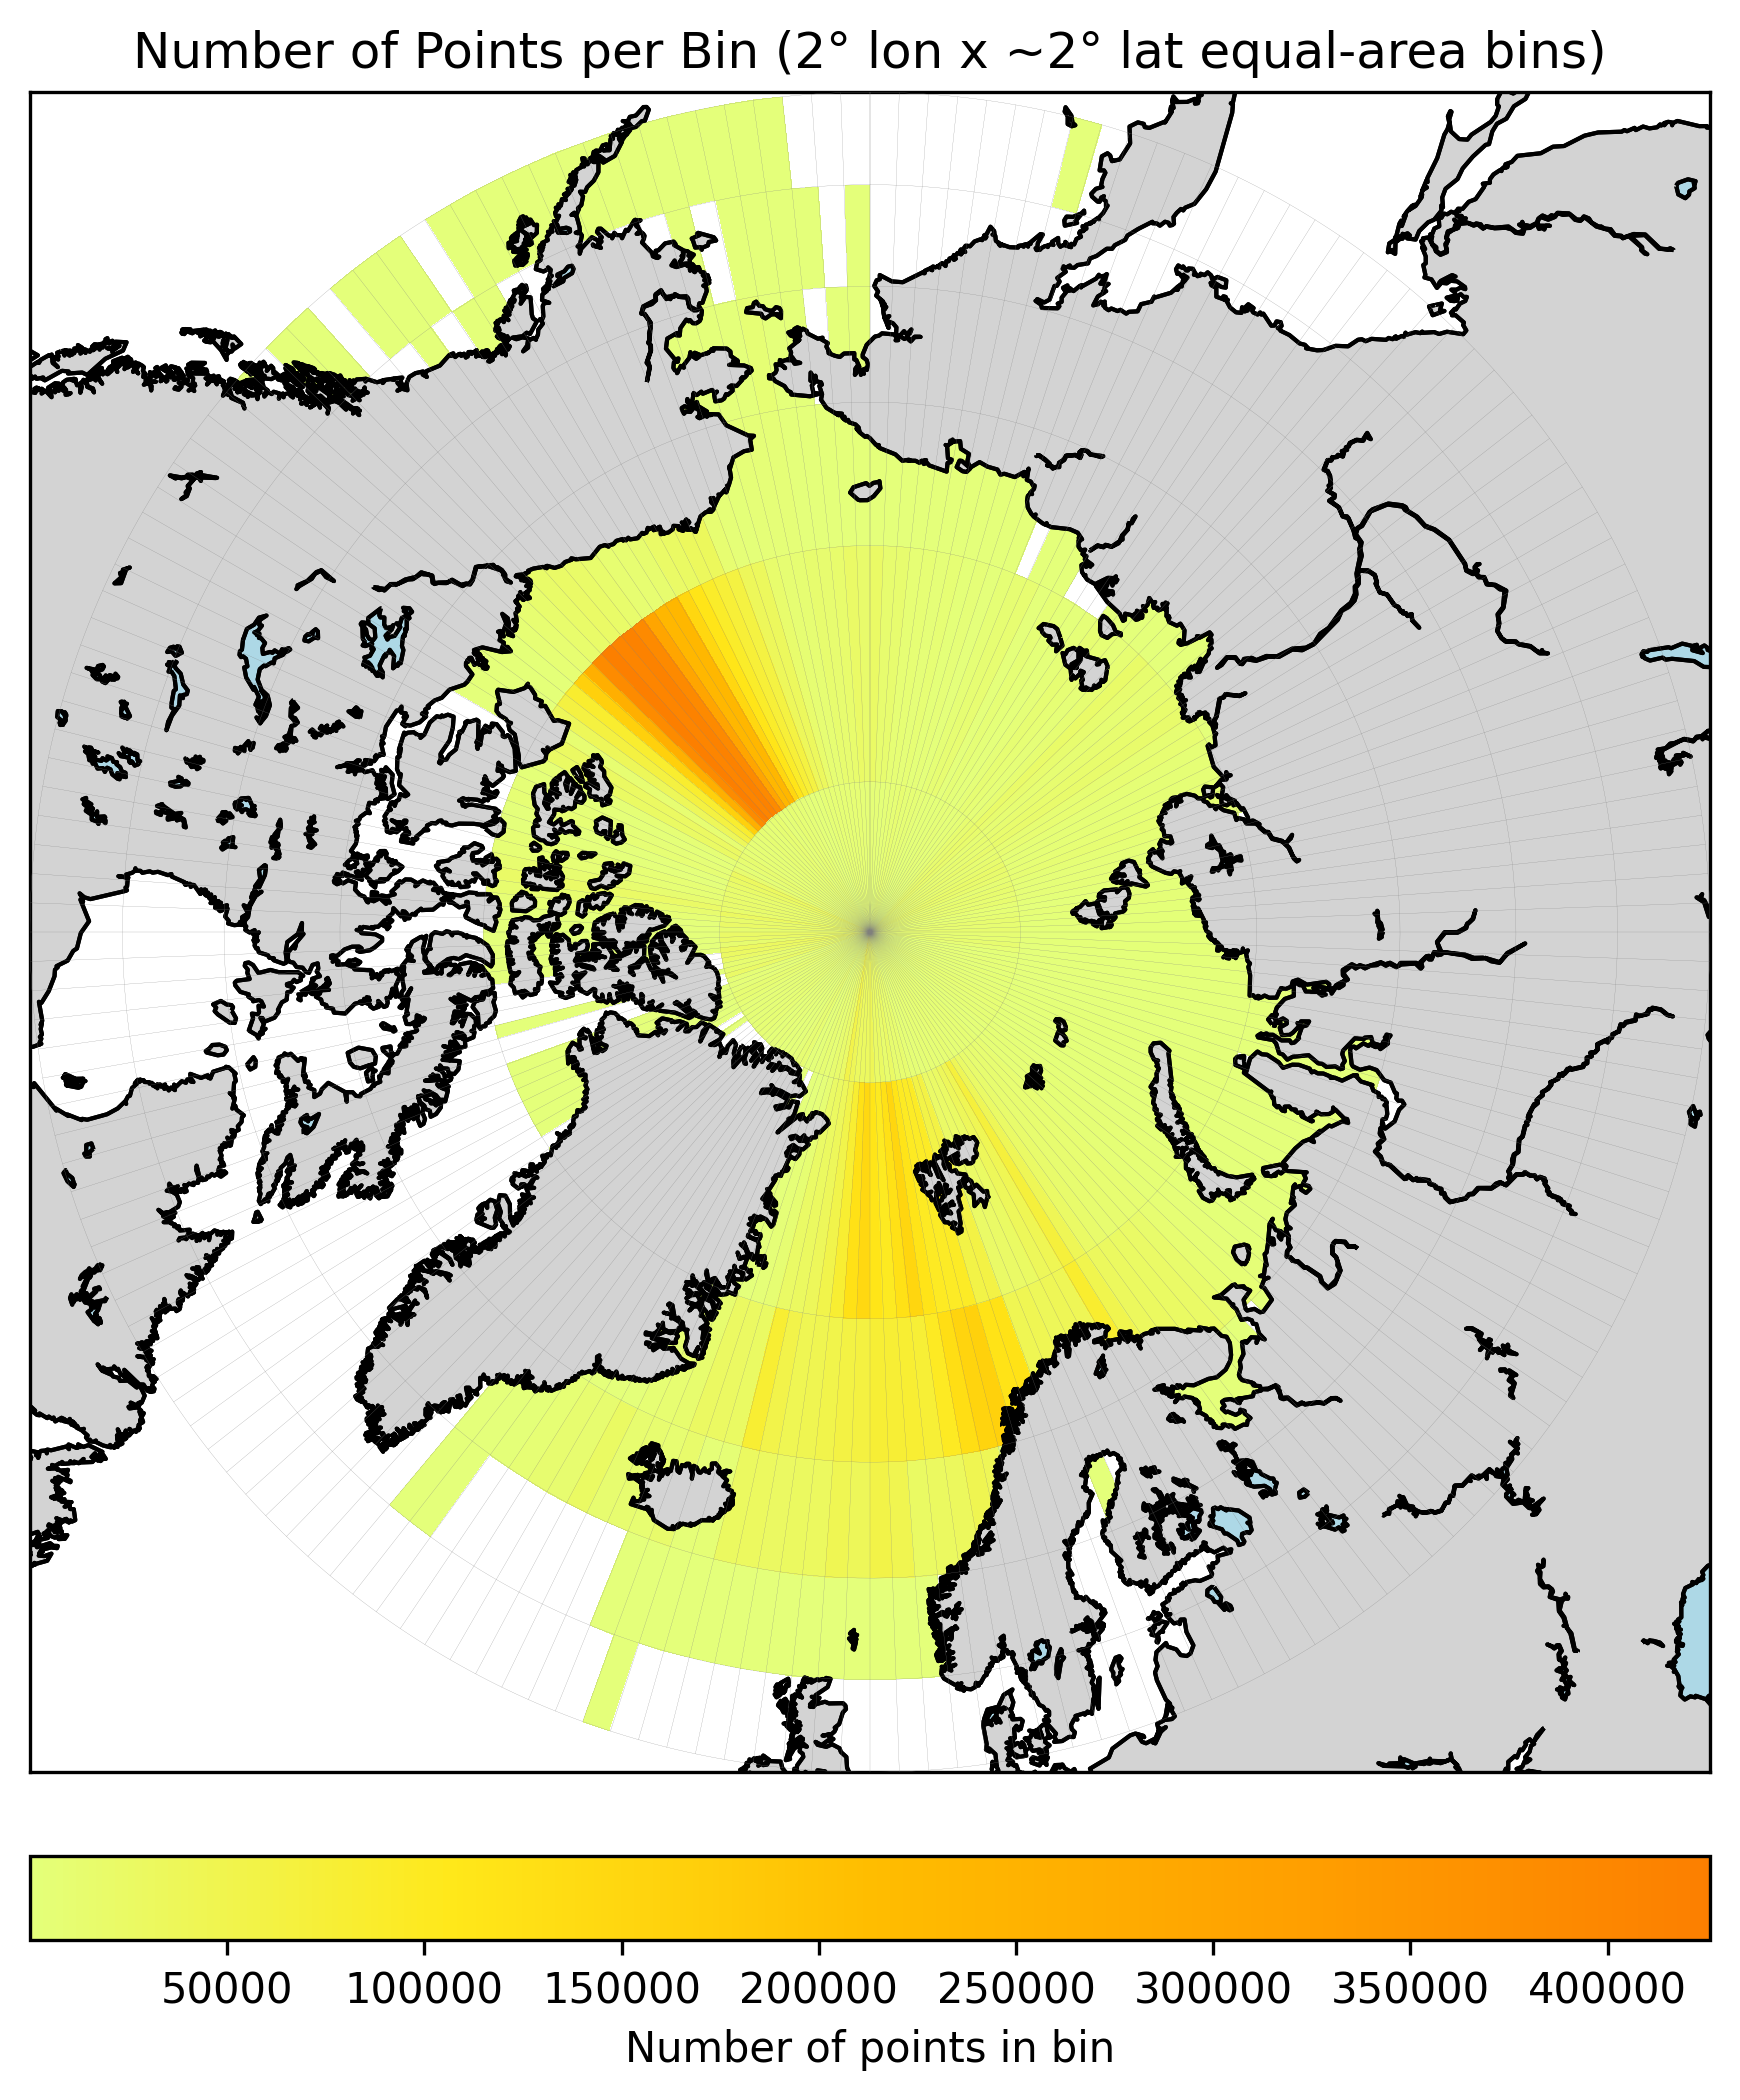

In [53]:
plot_heatmap_npts(df_ST, lon_step=2, lat_step=2)

In [8]:
# # find bins with more than 28k points (the transition point at 99% quantile) and save the points in those bins as df
# def get_points_bins_over_thresh(df,thresh, n_lon_bins=72, n_lat_bins=9, projection='npstere'):
#     # Get lat-lon values
#     lat_min = df['Latitude_[deg_N]'].min()
#     lon_vals = df['Longitude_[deg_E]'].values
#     lat_vals = df['Latitude_[deg_N]'].values

#     # Deinfe lat lon bin edges
#     lon_bins = np.linspace(-180, 180, n_lon_bins + 1)
#     lat_bins = np.linspace(lat_min, 90, n_lat_bins + 1)

#     # Digitize points into bins
#     lon_idx = np.digitize(lon_vals, lon_bins) - 1
#     lat_idx = np.digitize(lat_vals, lat_bins) - 1

#     # Count number of profiles per bin
#     H = np.zeros((n_lon_bins, n_lat_bins), dtype=int)
#     for i in range(len(lon_vals)):
#         xi, yi = lon_idx[i], lat_idx[i]
#         if 0 <= xi < n_lon_bins and 0 <= yi < n_lat_bins:
#             H[xi, yi] += 1

#     # Get indices of bins that exceed the threshold
#     bins_over_thresh = np.argwhere(H > thresh)

#     # Create a mask for points that fall into bins over the threshold
#     mask = np.zeros(len(df), dtype=bool)
#     for xi, yi in bins_over_thresh:
#         mask |= (lon_idx == xi) & (lat_idx == yi)

#     # Filter the original dataframe to get points in bins over the threshold
#     df_over_thresh = df[mask]

#     return df_over_thresh

In [43]:
def _make_bins(lon_step, lat_step, lon_min=-180, lon_max=180, lat_min=55, lat_max=90):
    lon_bins = np.arange(lon_min, lon_max + lon_step, lon_step)
    sin_step = np.sin(np.radians(lat_step)) - np.sin(np.radians(0))
    sin_bins = np.arange(
        np.sin(np.radians(lat_min)),
        np.sin(np.radians(lat_max)) + sin_step,
        sin_step
    )
    lat_bins = np.degrees(np.arcsin(np.clip(sin_bins, -1, 1)))
    return lon_bins, lat_bins

In [44]:
def get_points_bins_over_thresh(df, thresh, lon_step=5, lat_step=5):
    
    # === Identical bin construction via shared helper ===
    lon_bins, lat_bins = _make_bins(lon_step, lat_step)
    n_lon_bins = len(lon_bins) - 1
    n_lat_bins = len(lat_bins) - 1
    # ====================================================

    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values

    lon_idx = np.clip(np.digitize(lon_vals, lon_bins) - 1, 0, n_lon_bins - 1)
    lat_idx = np.clip(np.digitize(lat_vals, lat_bins) - 1, 0, n_lat_bins - 1)

    # Count number of profiles per bin
    H = np.zeros((n_lon_bins, n_lat_bins), dtype=int)
    for i in range(len(lon_vals)):
        H[lon_idx[i], lat_idx[i]] += 1

    # Build mask for points in bins over threshold
    bins_over_thresh = np.argwhere(H > thresh)
    mask = np.zeros(len(df), dtype=bool)
    for xi, yi in bins_over_thresh:
        mask |= (lon_idx == xi) & (lat_idx == yi)

    return df[mask]

In [45]:
over_thresh = get_points_bins_over_thresh(df_ST, thresh=465_000)

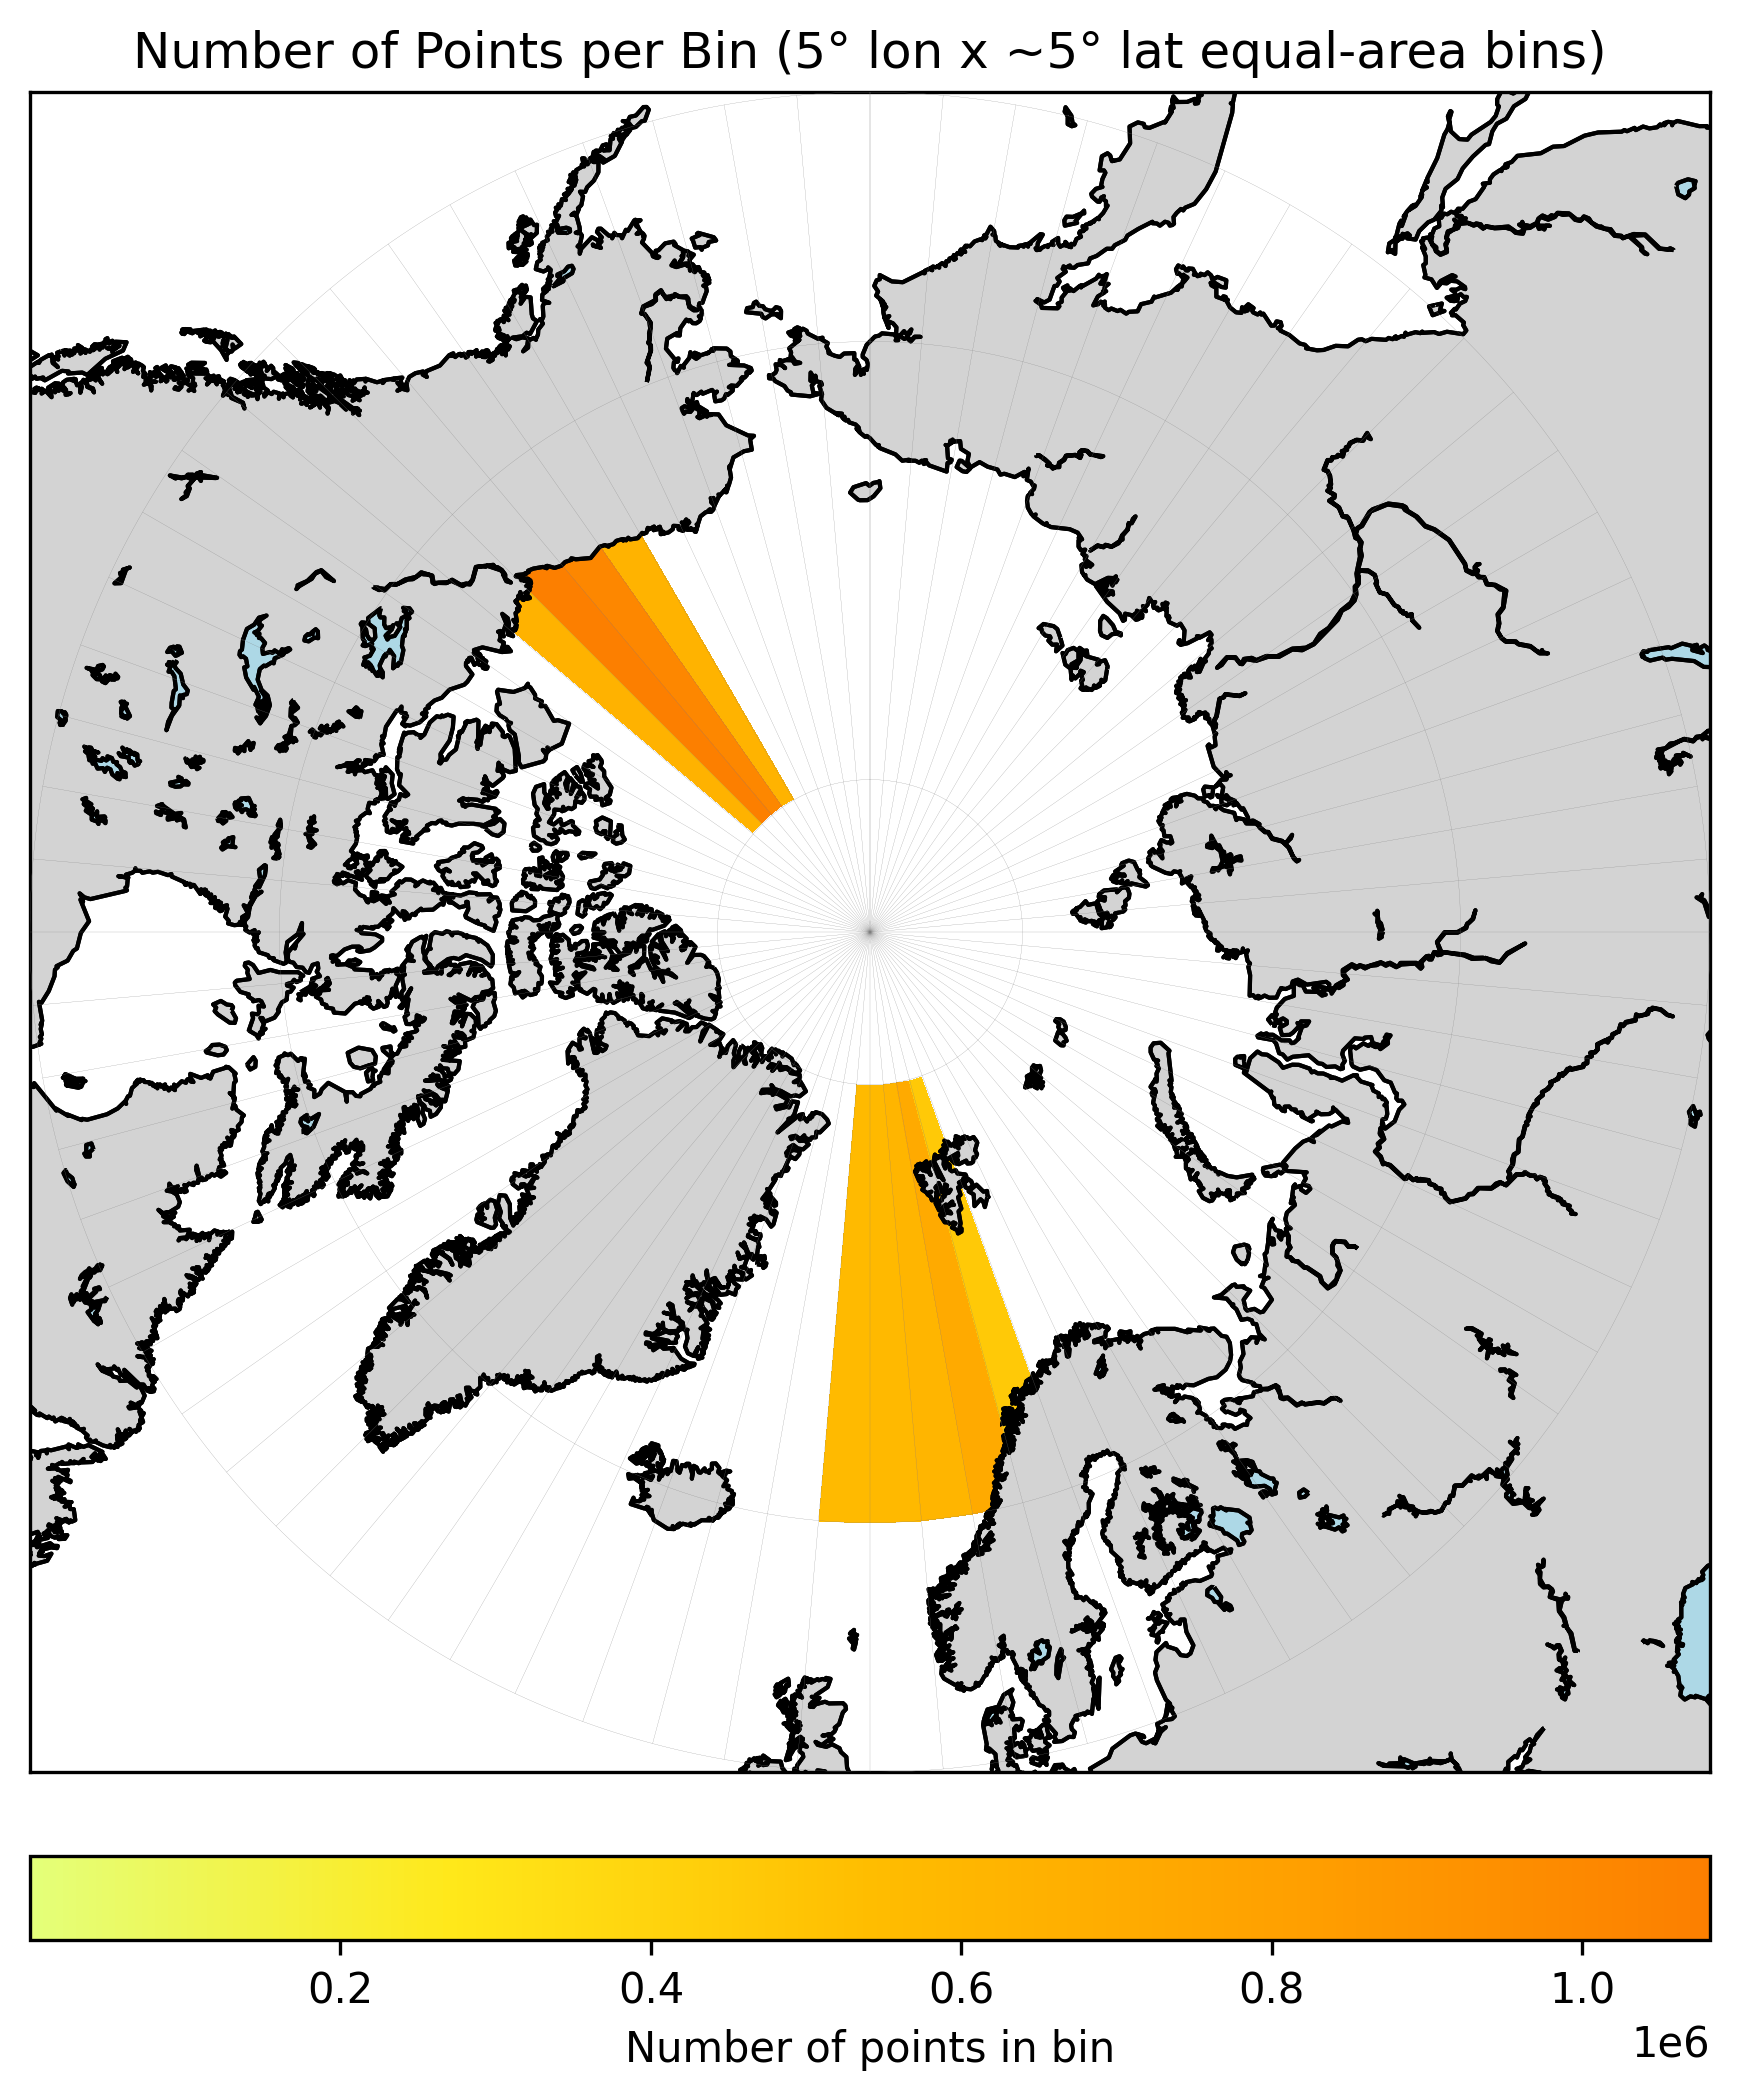

In [46]:
plot_heatmap_npts(over_thresh, lon_step=5, lat_step=5)

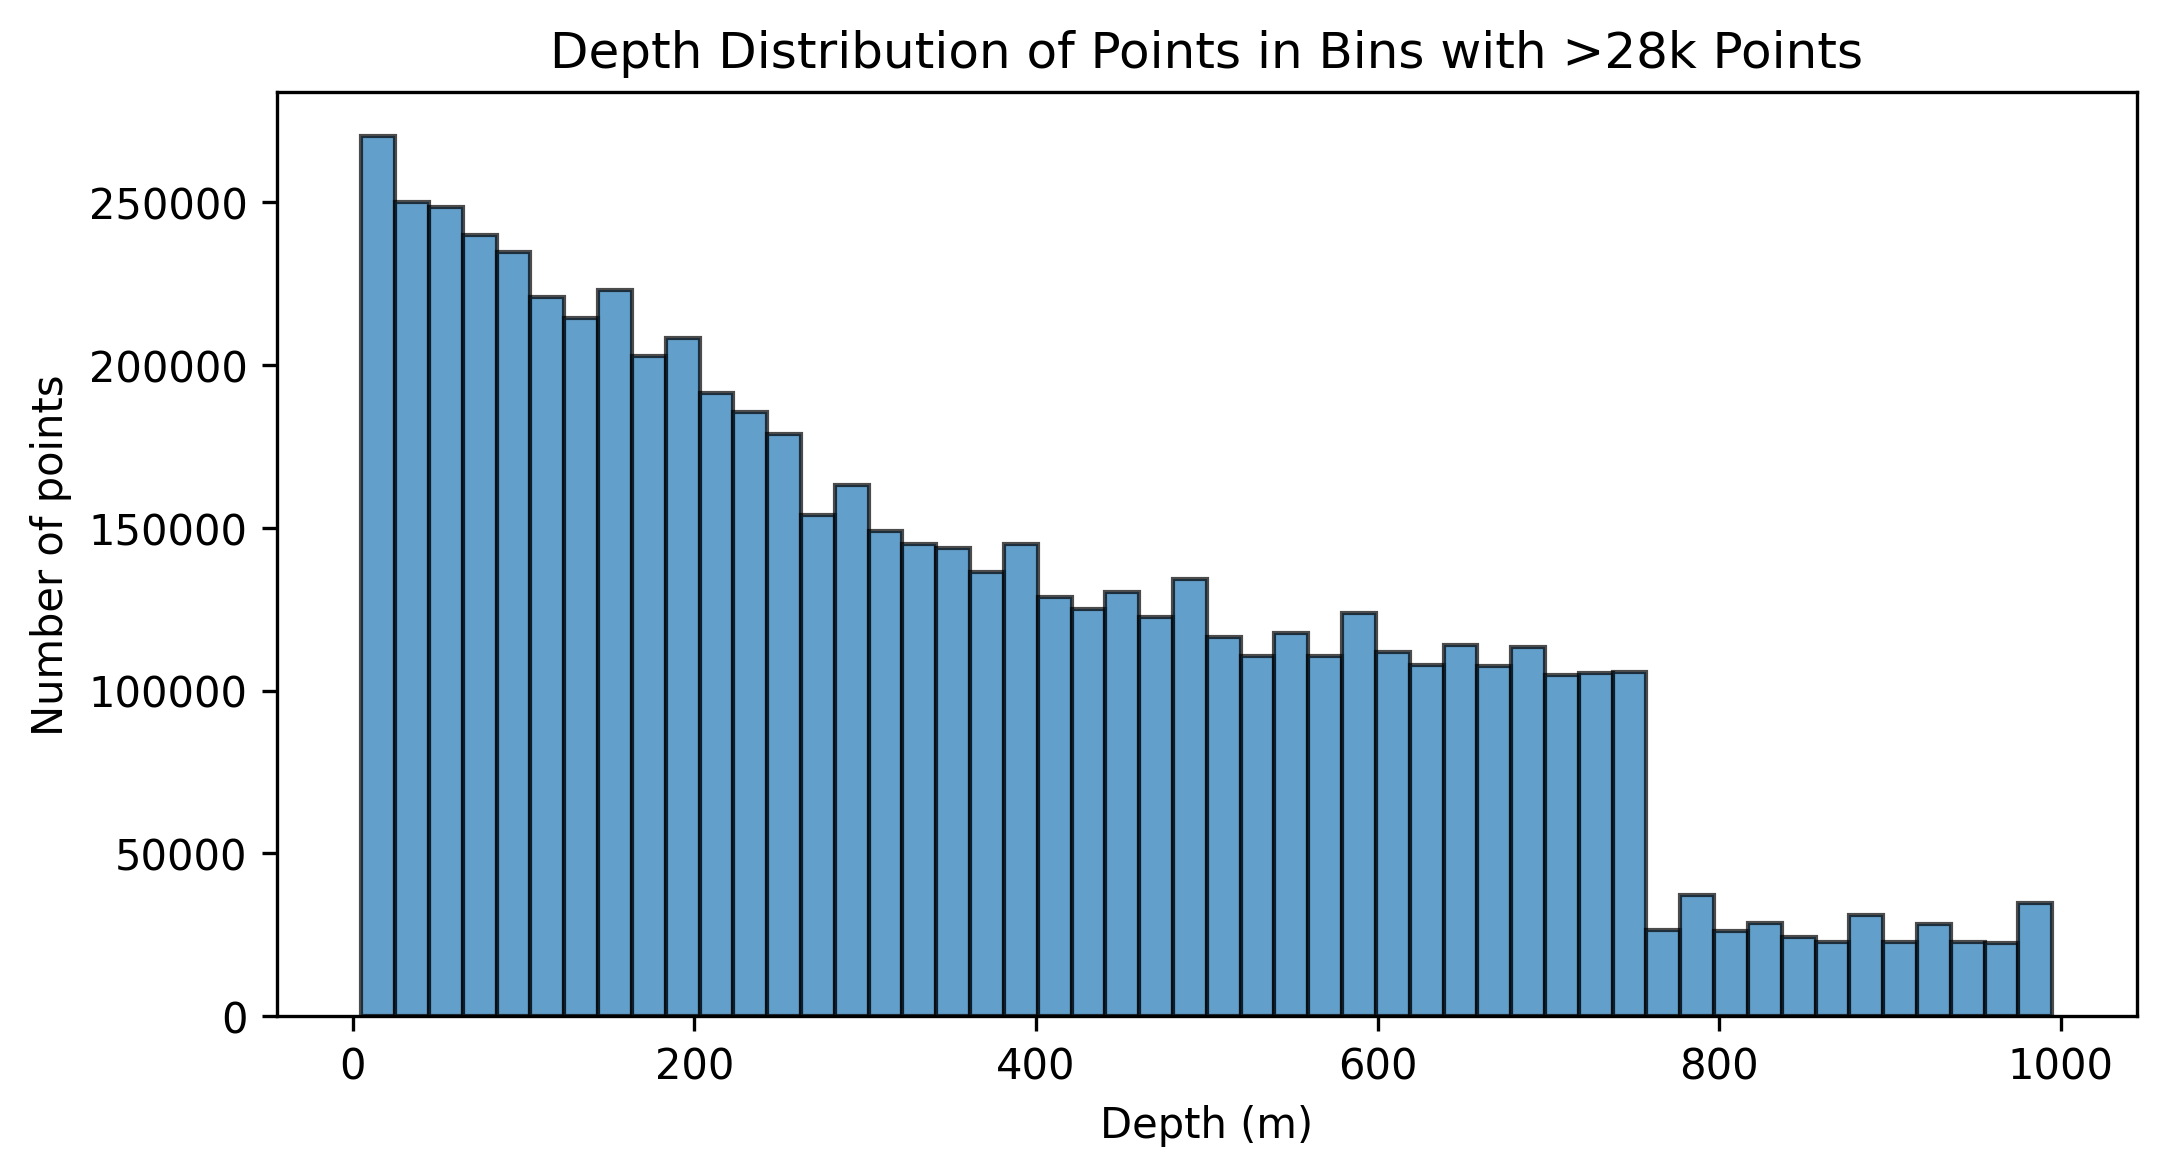

In [47]:
# depth histogram of points in bins over threshold
plt.figure(figsize=(8, 4), dpi=300)
plt.hist(over_thresh['Depth_[m]'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Depth (m)')
plt.ylabel('Number of points')
plt.title('Depth Distribution of Points in Bins with >28k Points')
plt.show()

In [48]:
def sample_cap_bins(df, thresh, lon_step=5, lat_step=5):
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 55, 90

    lon_bins = np.arange(lon_min, lon_max + lon_step, lon_step)

    sin_step = np.sin(np.radians(lat_step)) - np.sin(np.radians(0))
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.arange(sin_min, sin_max + sin_step, sin_step)
    lat_bins = np.degrees(np.arcsin(np.clip(sin_bins, -1, 1)))

    n_lon_bins = len(lon_bins) - 1
    n_lat_bins = len(lat_bins) - 1

    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values

    lon_idx = np.clip(np.digitize(lon_vals, lon_bins) - 1, 0, n_lon_bins - 1)
    lat_idx = np.clip(np.digitize(lat_vals, lat_bins) - 1, 0, n_lat_bins - 1)

    bin_members = defaultdict(list)
    for i in range(len(lon_vals)):
        bin_members[(lon_idx[i], lat_idx[i])].append(i)

    sampled_indices = []
    for (xi, yi), members in bin_members.items():
        if len(members) > thresh:
            sampled_indices.extend(
                np.random.choice(members, size=thresh, replace=False).tolist()
            )
        else:
            sampled_indices.extend(members)

    return df.iloc[sampled_indices].copy()

In [49]:
df_sampled = sample_cap_bins(df_ST, thresh=465_000, lon_step=5, lat_step=5)

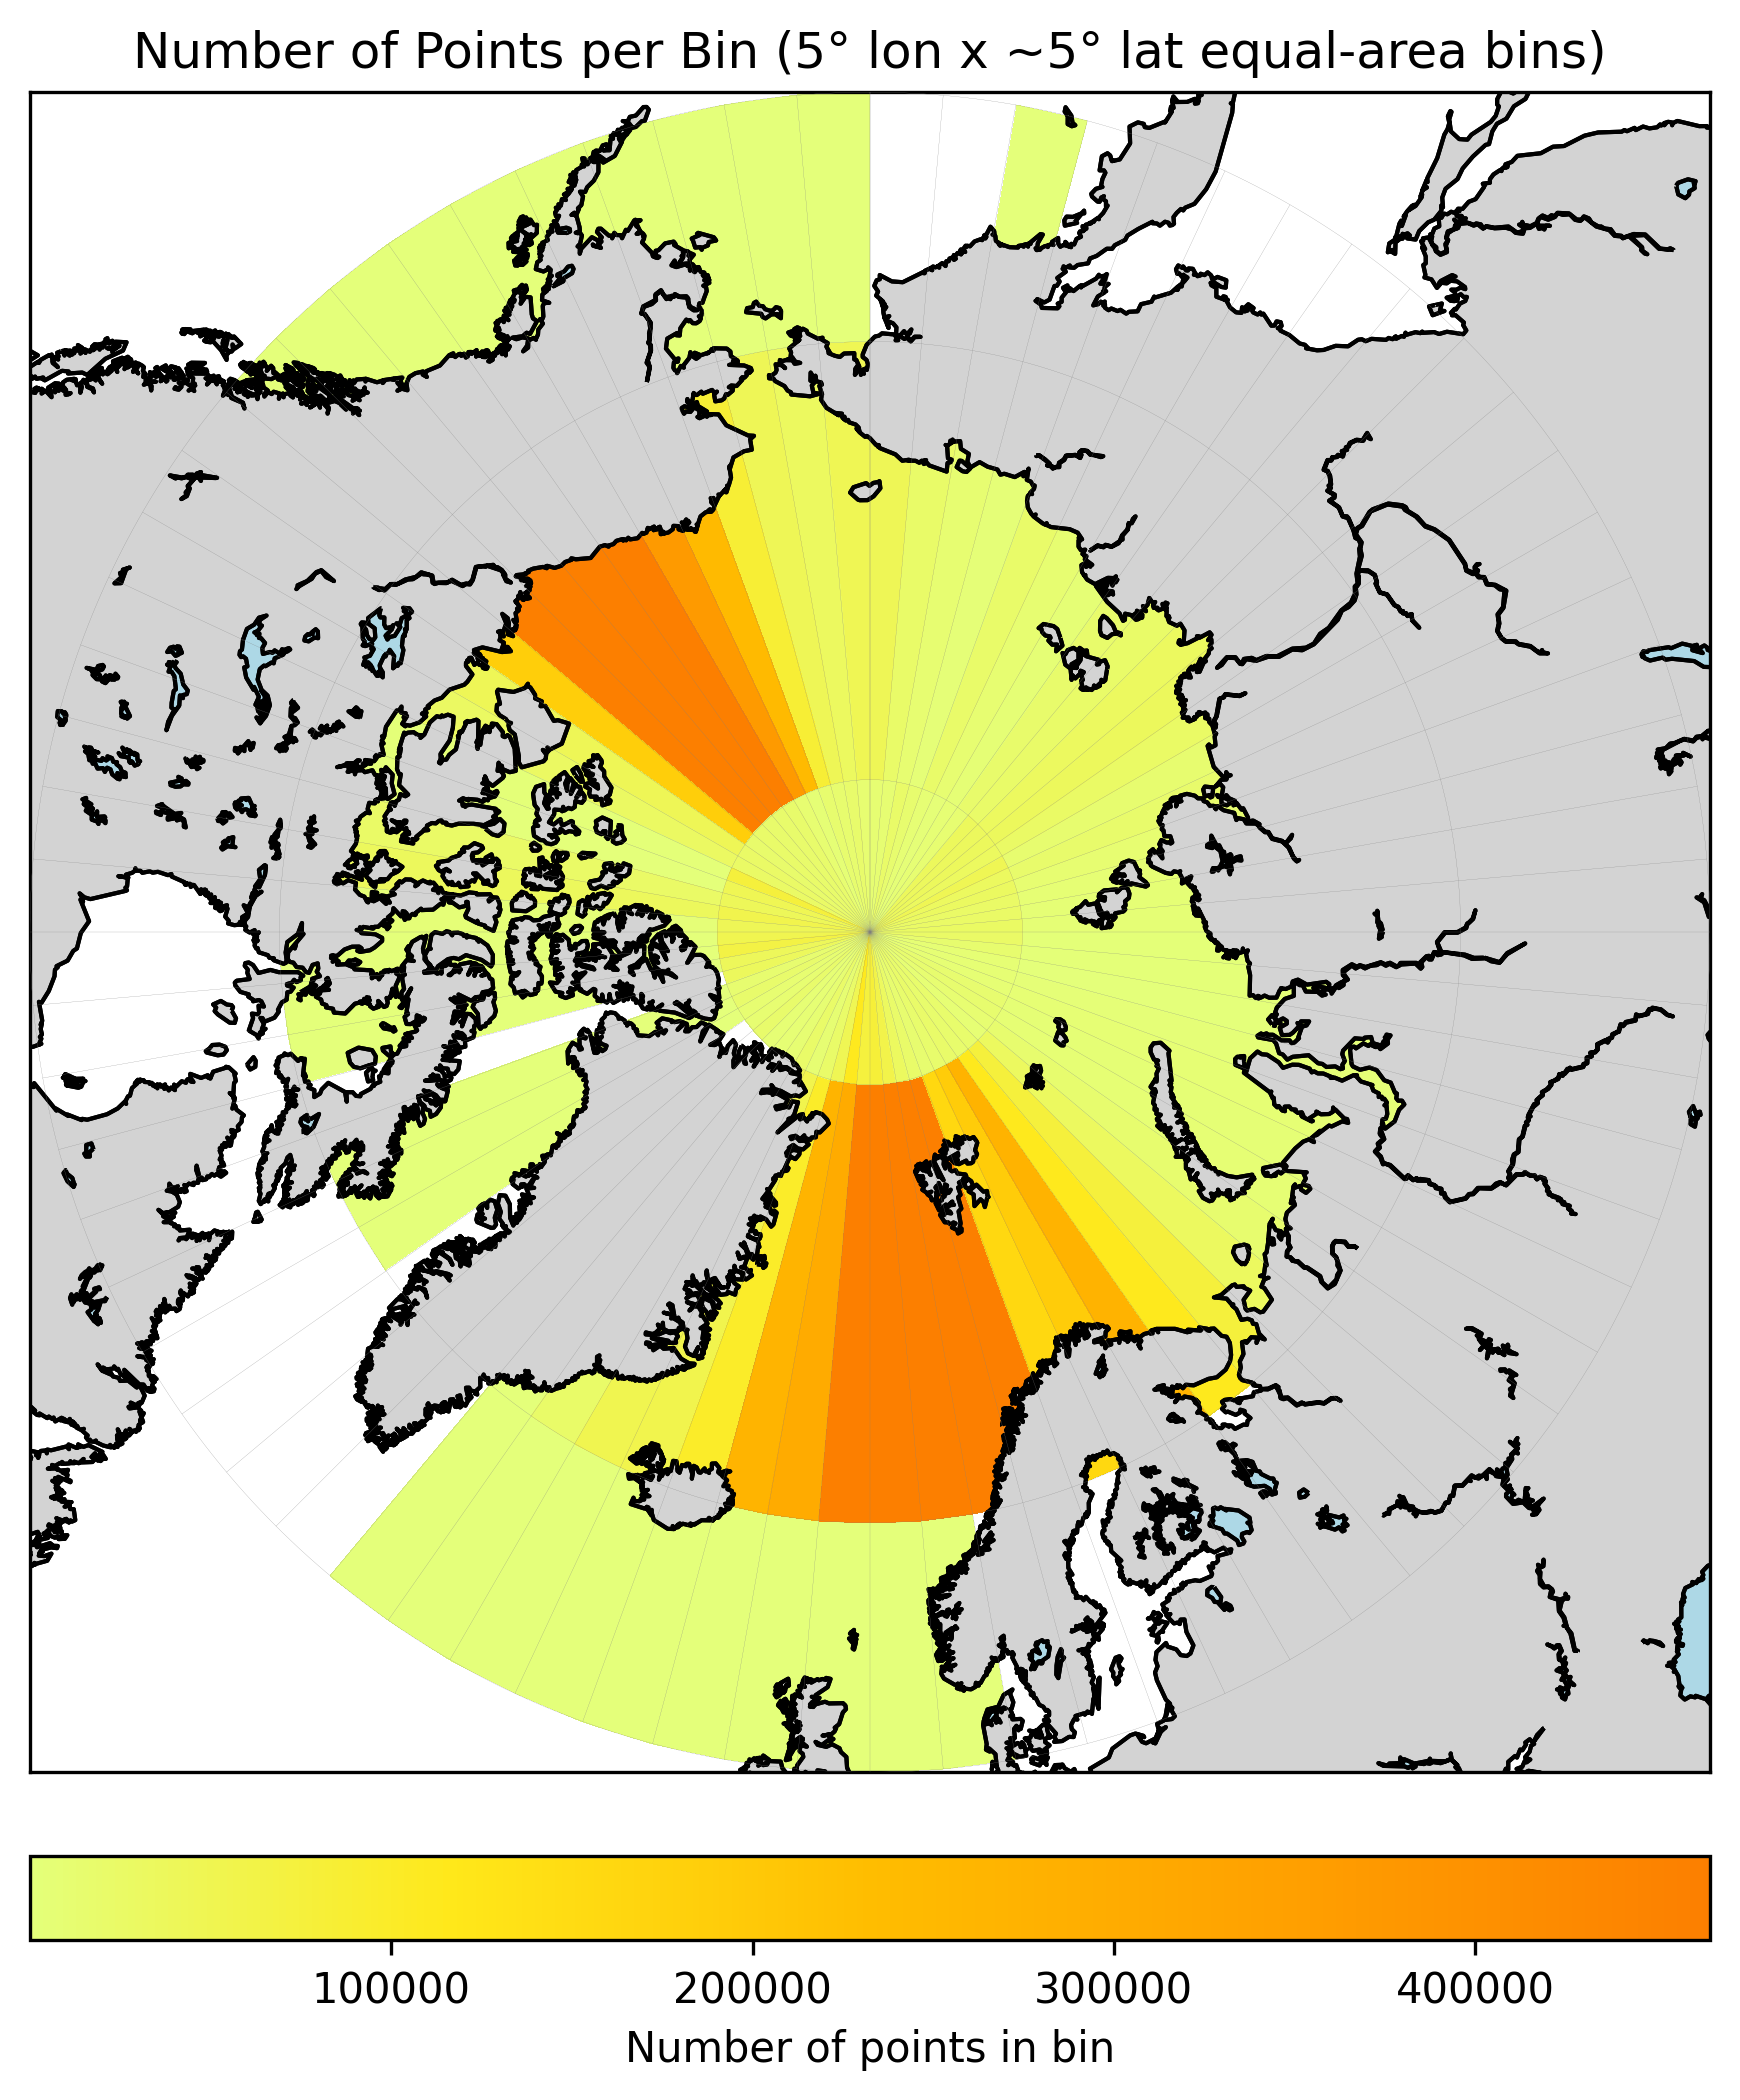

In [50]:
plot_heatmap_npts(df_sampled, lon_step=5, lat_step=5)

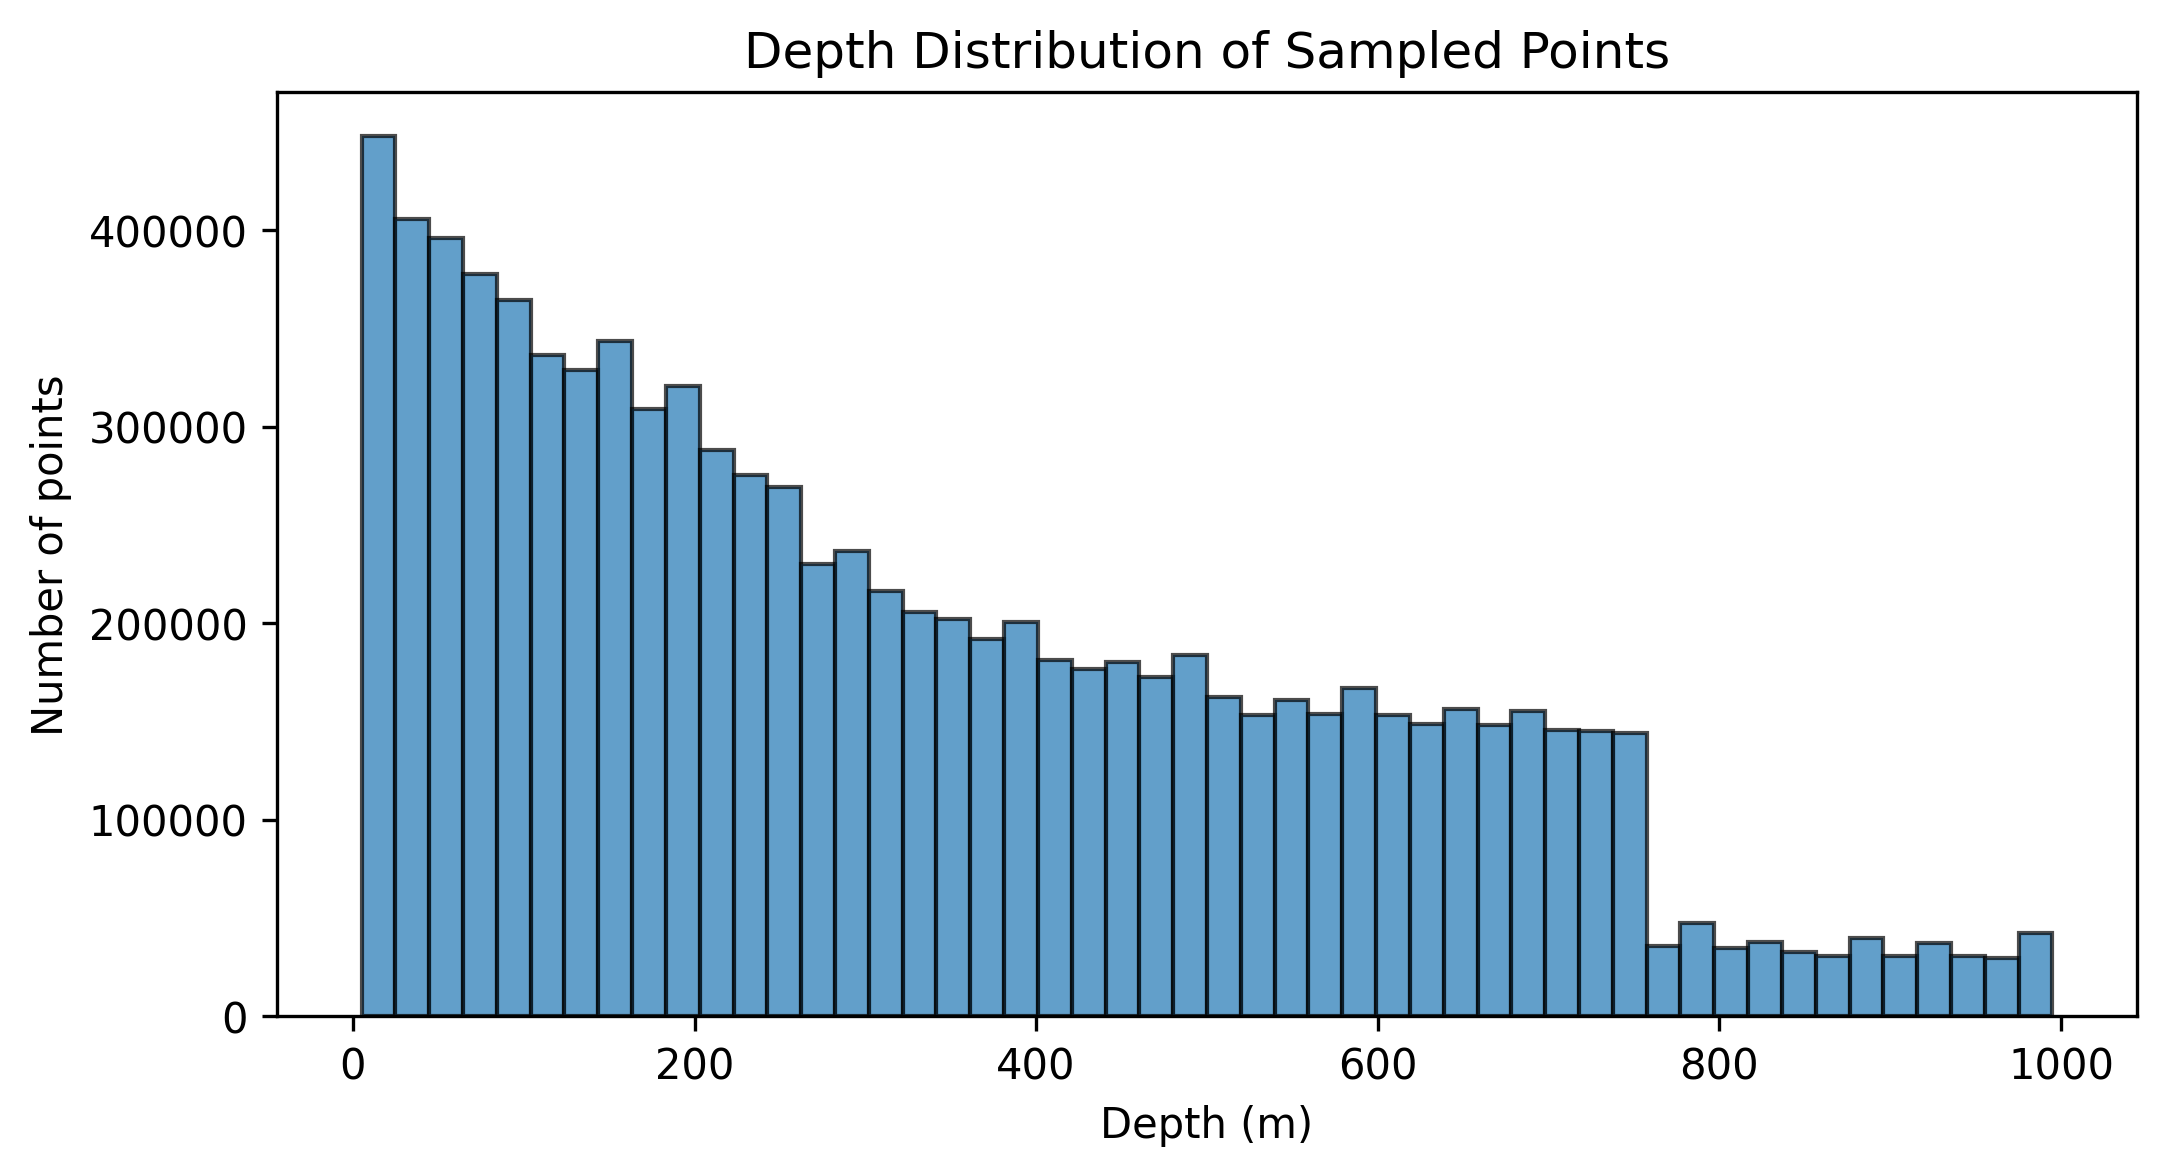

In [51]:
# Depth histogram of sampled dataframe
plt.figure(figsize=(8, 4), dpi=300)
plt.hist(df_sampled['Depth_[m]'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Depth (m)')
plt.ylabel('Number of points')
plt.title('Depth Distribution of Sampled Points')
plt.show()

In [52]:
profileNo_vs_latlon_bins(df_sampled, lat_step=5, lon_step=5, show_threshold=True, threshold_quantile=0.99)

# Projection: polar stereographic projection

In [18]:
def plot_heatmap_npts_xy(ds_cleaned, n_x_bins=100, n_y_bins=100, bin_max=None, projection='npstere', projection_name='Polar Stereographic'):
    lat_min = ds_cleaned['Latitude_[deg_N]'].min()
    resolution = 'l'

    fig = plt.figure(figsize=(8, 8), dpi=300)
    m = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution=resolution)

    # Convert lat/lon → x/y (projection coordinates in meters)
    lon_vals = ds_cleaned['Longitude_[deg_E]'].values
    lat_vals = ds_cleaned['Latitude_[deg_N]'].values

    # Reproject lat/lon to x/y
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()

    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # Grid to store max depth
    H = np.zeros((n_x_bins, n_y_bins))

    # Digitize into bins
    x_idx = np.digitize(x_vals, x_bins) - 1
    y_idx = np.digitize(y_vals, y_bins) - 1

    # Count number of points in each bin
    for i in range(len(x_vals)):
        xi, yi = x_idx[i], y_idx[i]
        if 0 <= xi < n_x_bins and 0 <= yi < n_y_bins:
            H[xi, yi] += 1

    # Create meshgrid for plotting
    X, Y = np.meshgrid(x_bins, y_bins)

    # Colormap
    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    if bin_max is None:
        bin_max = H.max()

    # Plot heatmap
    m.pcolormesh(X, Y, H.T, cmap=cmap, vmin=1, vmax=bin_max)

    # Draw bin grid (in xy space)
    for xb in x_bins:
        plt.plot([xb]*len(y_bins), y_bins, color='grey', linewidth=0.05, zorder=3)
    for yb in y_bins:
        plt.plot(x_bins, [yb]*len(x_bins), color='grey', linewidth=0.05, zorder=3)

    # Plot coastlines on top
    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='lightblue')

    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Number of points per bin')

    plt.xticks([])
    plt.yticks([])
    plt.title('Number of Points per Bin in '+ f'({projection_name} Projection)')

    plt.show()

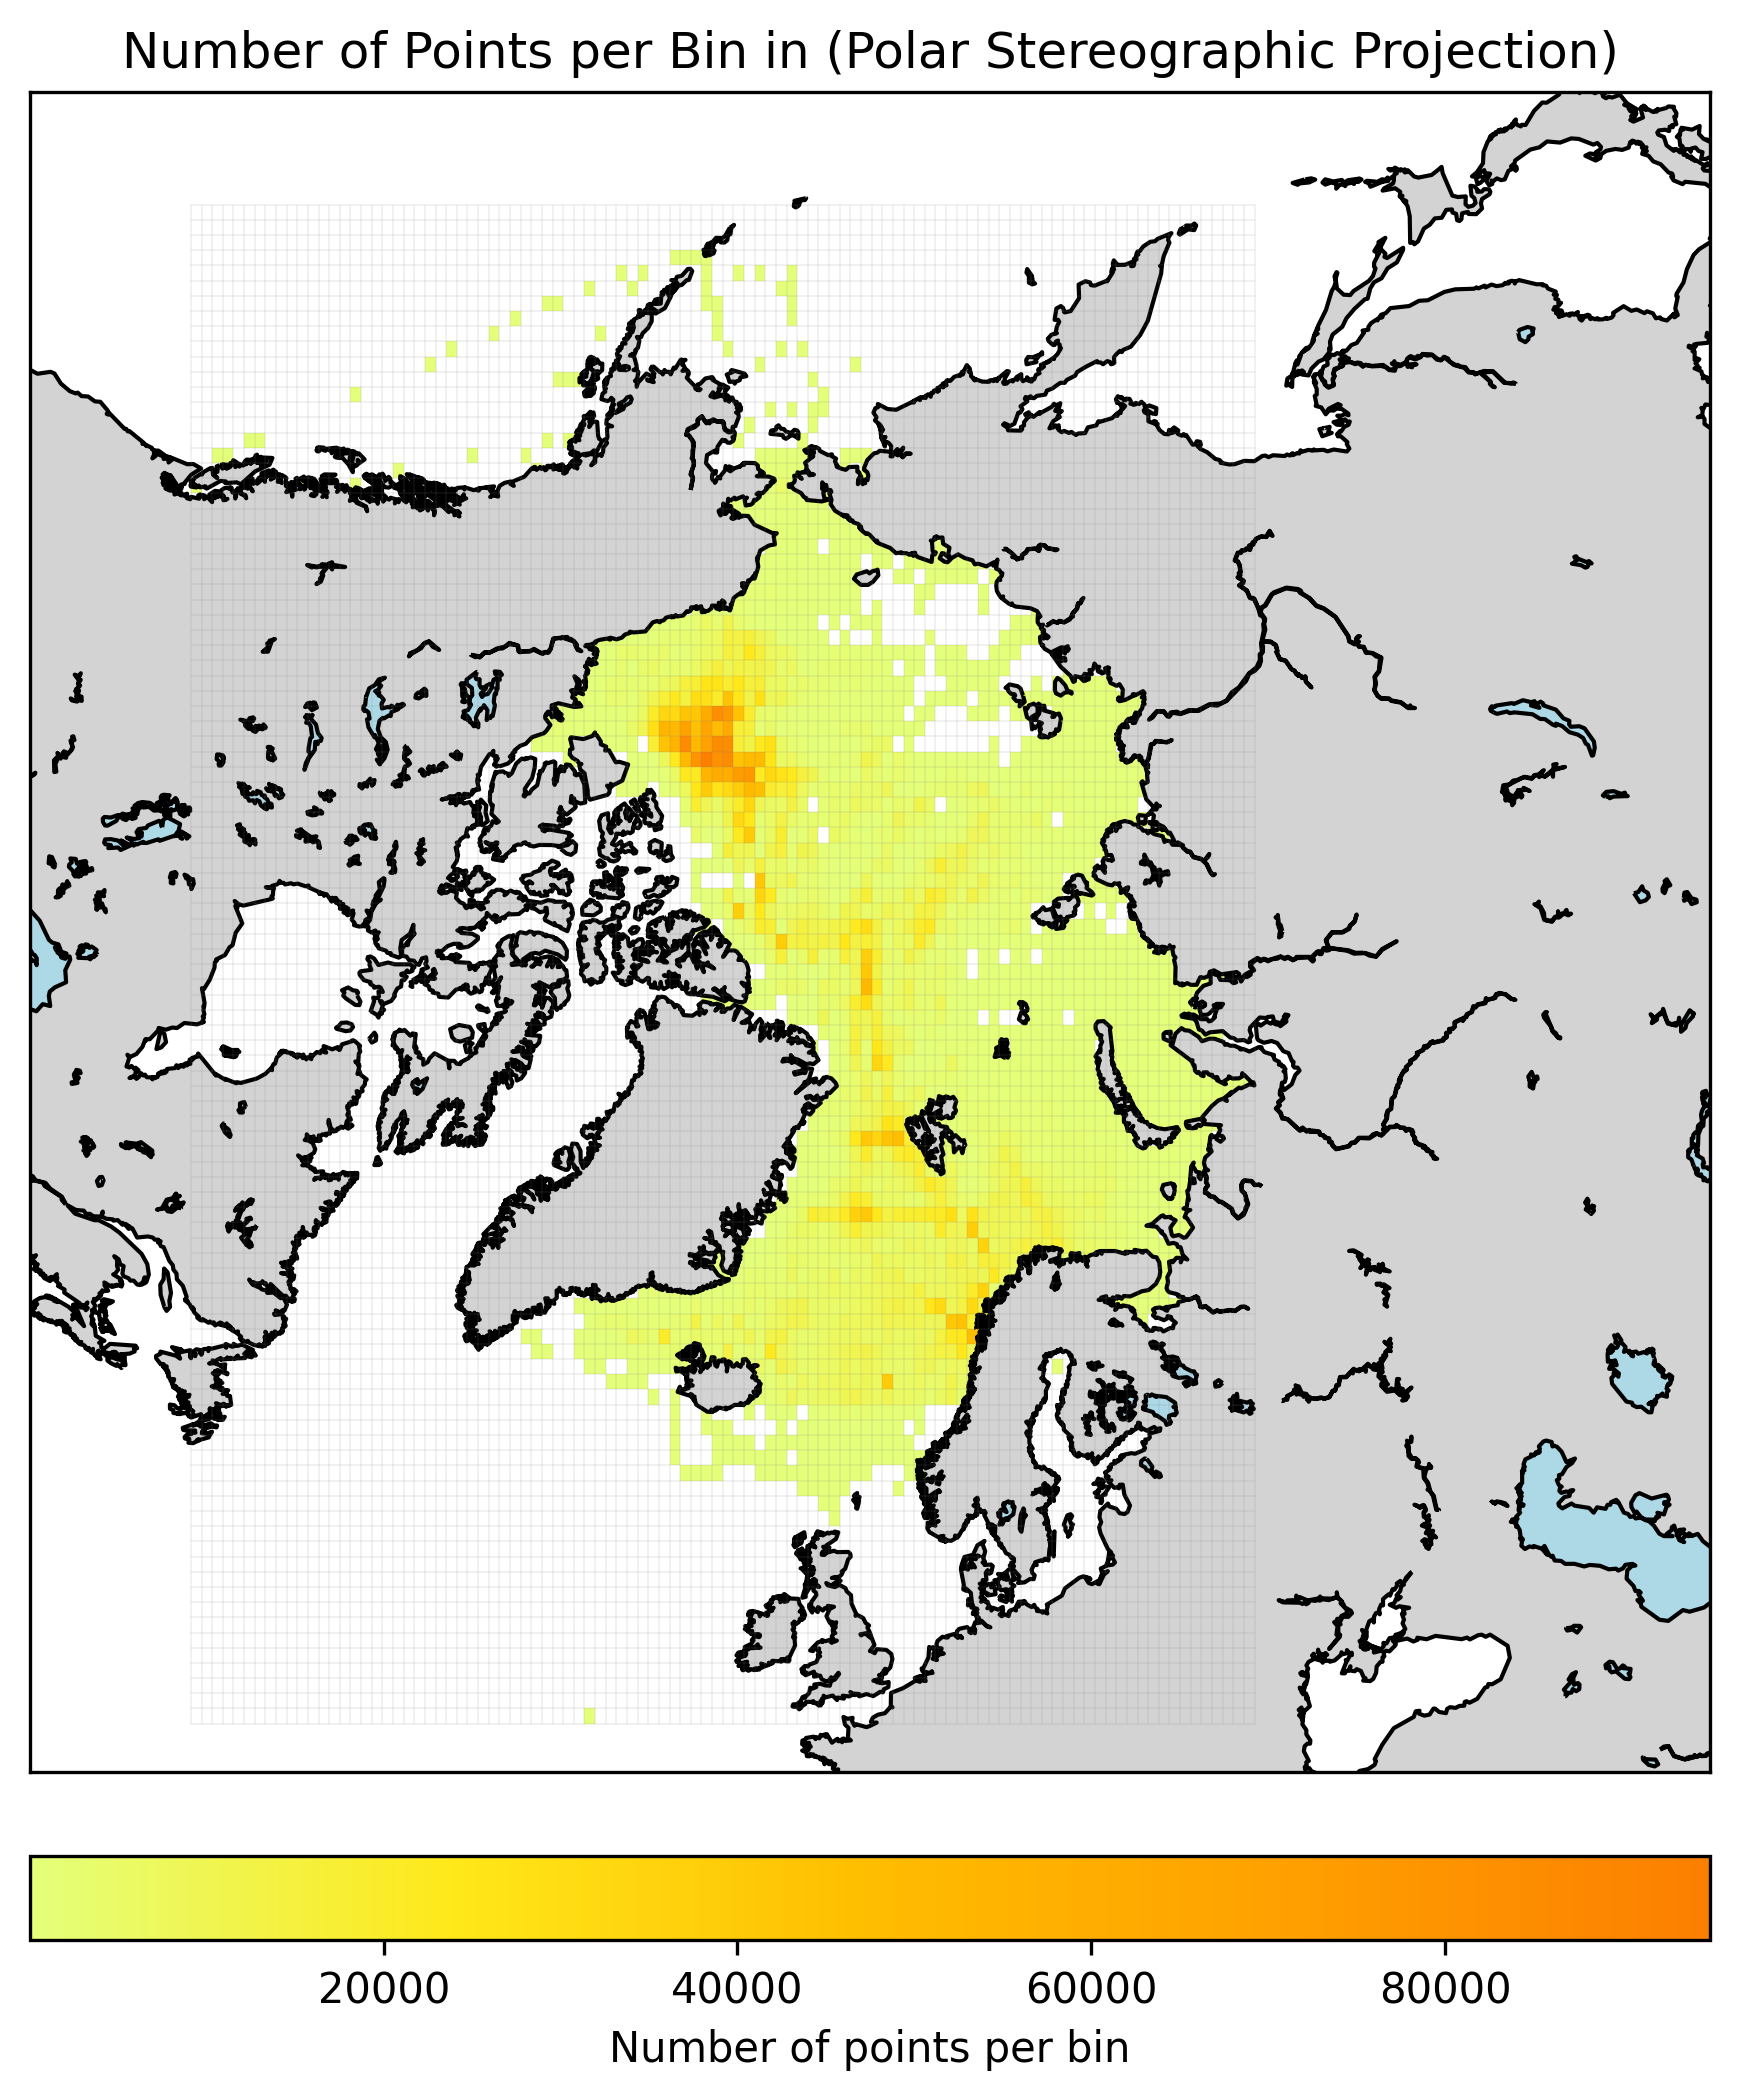

In [19]:
plot_heatmap_npts_xy(df_ST, n_x_bins=100, n_y_bins=100, projection='npstere', projection_name='Polar Stereographic')

In [20]:
def profileNo_vs_xy_bins(
    df: pd.DataFrame,
    n_x_bins: int = 100,
    n_y_bins: int = 100,
    show_threshold: bool = False,
    threshold_quantile: float = 0.95,
    projection: str = 'npstere'
) -> None:
    """
    Plot the number of profiles in each bin using polar stereographic projection.
    Args:
        df (pd.DataFrame): The dataset to plot.
        n_x_bins (int): Number of bins in the x direction. Defaults to 100.
        n_y_bins (int): Number of bins in the y direction. Defaults to 100.
        show_threshold (bool, optional): Whether to show the threshold marker. Defaults to False.
        threshold_quantile (float, optional): The quantile value for threshold calculation. Defaults to 0.95.
        projection (str, optional): Basemap projection string. Defaults to 'npstere'.
    Returns:
        None
    """
    # Set up the polar stereographic projection
    lat_min = df['Latitude_[deg_N]'].min()
    m = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution='l')

    # Reproject lat/lon to x/y (projection coordinates in metres)
    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges in projected space
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()
    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # Digitize points into bins
    x_idx = np.digitize(x_vals, x_bins) - 1
    y_idx = np.digitize(y_vals, y_bins) - 1

    # Count number of profiles per bin
    H = np.zeros((n_x_bins, n_y_bins), dtype=int)
    for i in range(len(x_vals)):
        xi, yi = x_idx[i], y_idx[i]
        if 0 <= xi < n_x_bins and 0 <= yi < n_y_bins:
            H[xi, yi] += 1

    # Flatten to get non-zero bin counts (matching original behaviour of only counting occupied bins)
    g_len = H[H > 0].flatten().tolist()
    g_len_sorted = sorted(g_len)

    # Threshold / transition point detection
    transition_point = None
    if len(g_len_sorted) > 1:
        g_len_diff = np.diff(g_len_sorted)
        threshold = np.quantile(g_len_diff, threshold_quantile)
        for i in range(1, len(g_len_sorted)):
            if g_len_sorted[i] - g_len_sorted[i - 1] > threshold:
                transition_point = i - 1
                break

    # Build Plotly traces
    trace = go.Scatter(
        x=list(range(len(g_len_sorted))),
        y=g_len_sorted
    )

    if show_threshold and transition_point is not None:
        red_dot = go.Scatter(
            x=[transition_point],
            y=[g_len_sorted[transition_point]],
            mode='markers',
            marker=dict(color='red', size=10)
        )
        fig_data = [trace, red_dot]
    else:
        fig_data = [trace]

    layout = go.Layout(
        xaxis=dict(title='Bin No.'),
        yaxis=dict(title='Number of points per bin')
    )
    fig = go.Figure(data=fig_data, layout=layout)
    fig.show()

In [21]:
profileNo_vs_xy_bins(df_ST, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.95, projection='npstere')

In [22]:
profileNo_vs_xy_bins(df_ST, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.99, projection='npstere')

In [23]:
# find bins with more than 28k points (the transition point at 99% quantile) and save the points in those bins as df
def get_points_bins_over_thresh_xy(df,thresh, n_x_bins=100, n_y_bins=100, projection='npstere'):
    lat_min = df['Latitude_[deg_N]'].min()
    m = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution='l')

    # Reproject lat/lon to x/y (projection coordinates in metres)
    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges in projected space
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()
    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # Digitize points into bins
    x_idx = np.digitize(x_vals, x_bins) - 1
    y_idx = np.digitize(y_vals, y_bins) - 1

    # Count number of profiles per bin
    H = np.zeros((n_x_bins, n_y_bins), dtype=int)
    for i in range(len(x_vals)):
        xi, yi = x_idx[i], y_idx[i]
        if 0 <= xi < n_x_bins and 0 <= yi < n_y_bins:
            H[xi, yi] += 1

    # Get indices of bins that exceed the threshold
    bins_over_thresh = np.argwhere(H > thresh)

    # Create a mask for points that fall into bins over the threshold
    mask = np.zeros(len(df), dtype=bool)
    for xi, yi in bins_over_thresh:
        mask |= (x_idx == xi) & (y_idx == yi)

    # Filter the original dataframe to get points in bins over the threshold
    df_over_thresh = df[mask]

    return df_over_thresh

In [24]:
df_over_thresh = get_points_bins_over_thresh_xy(df_ST, thresh=28000)

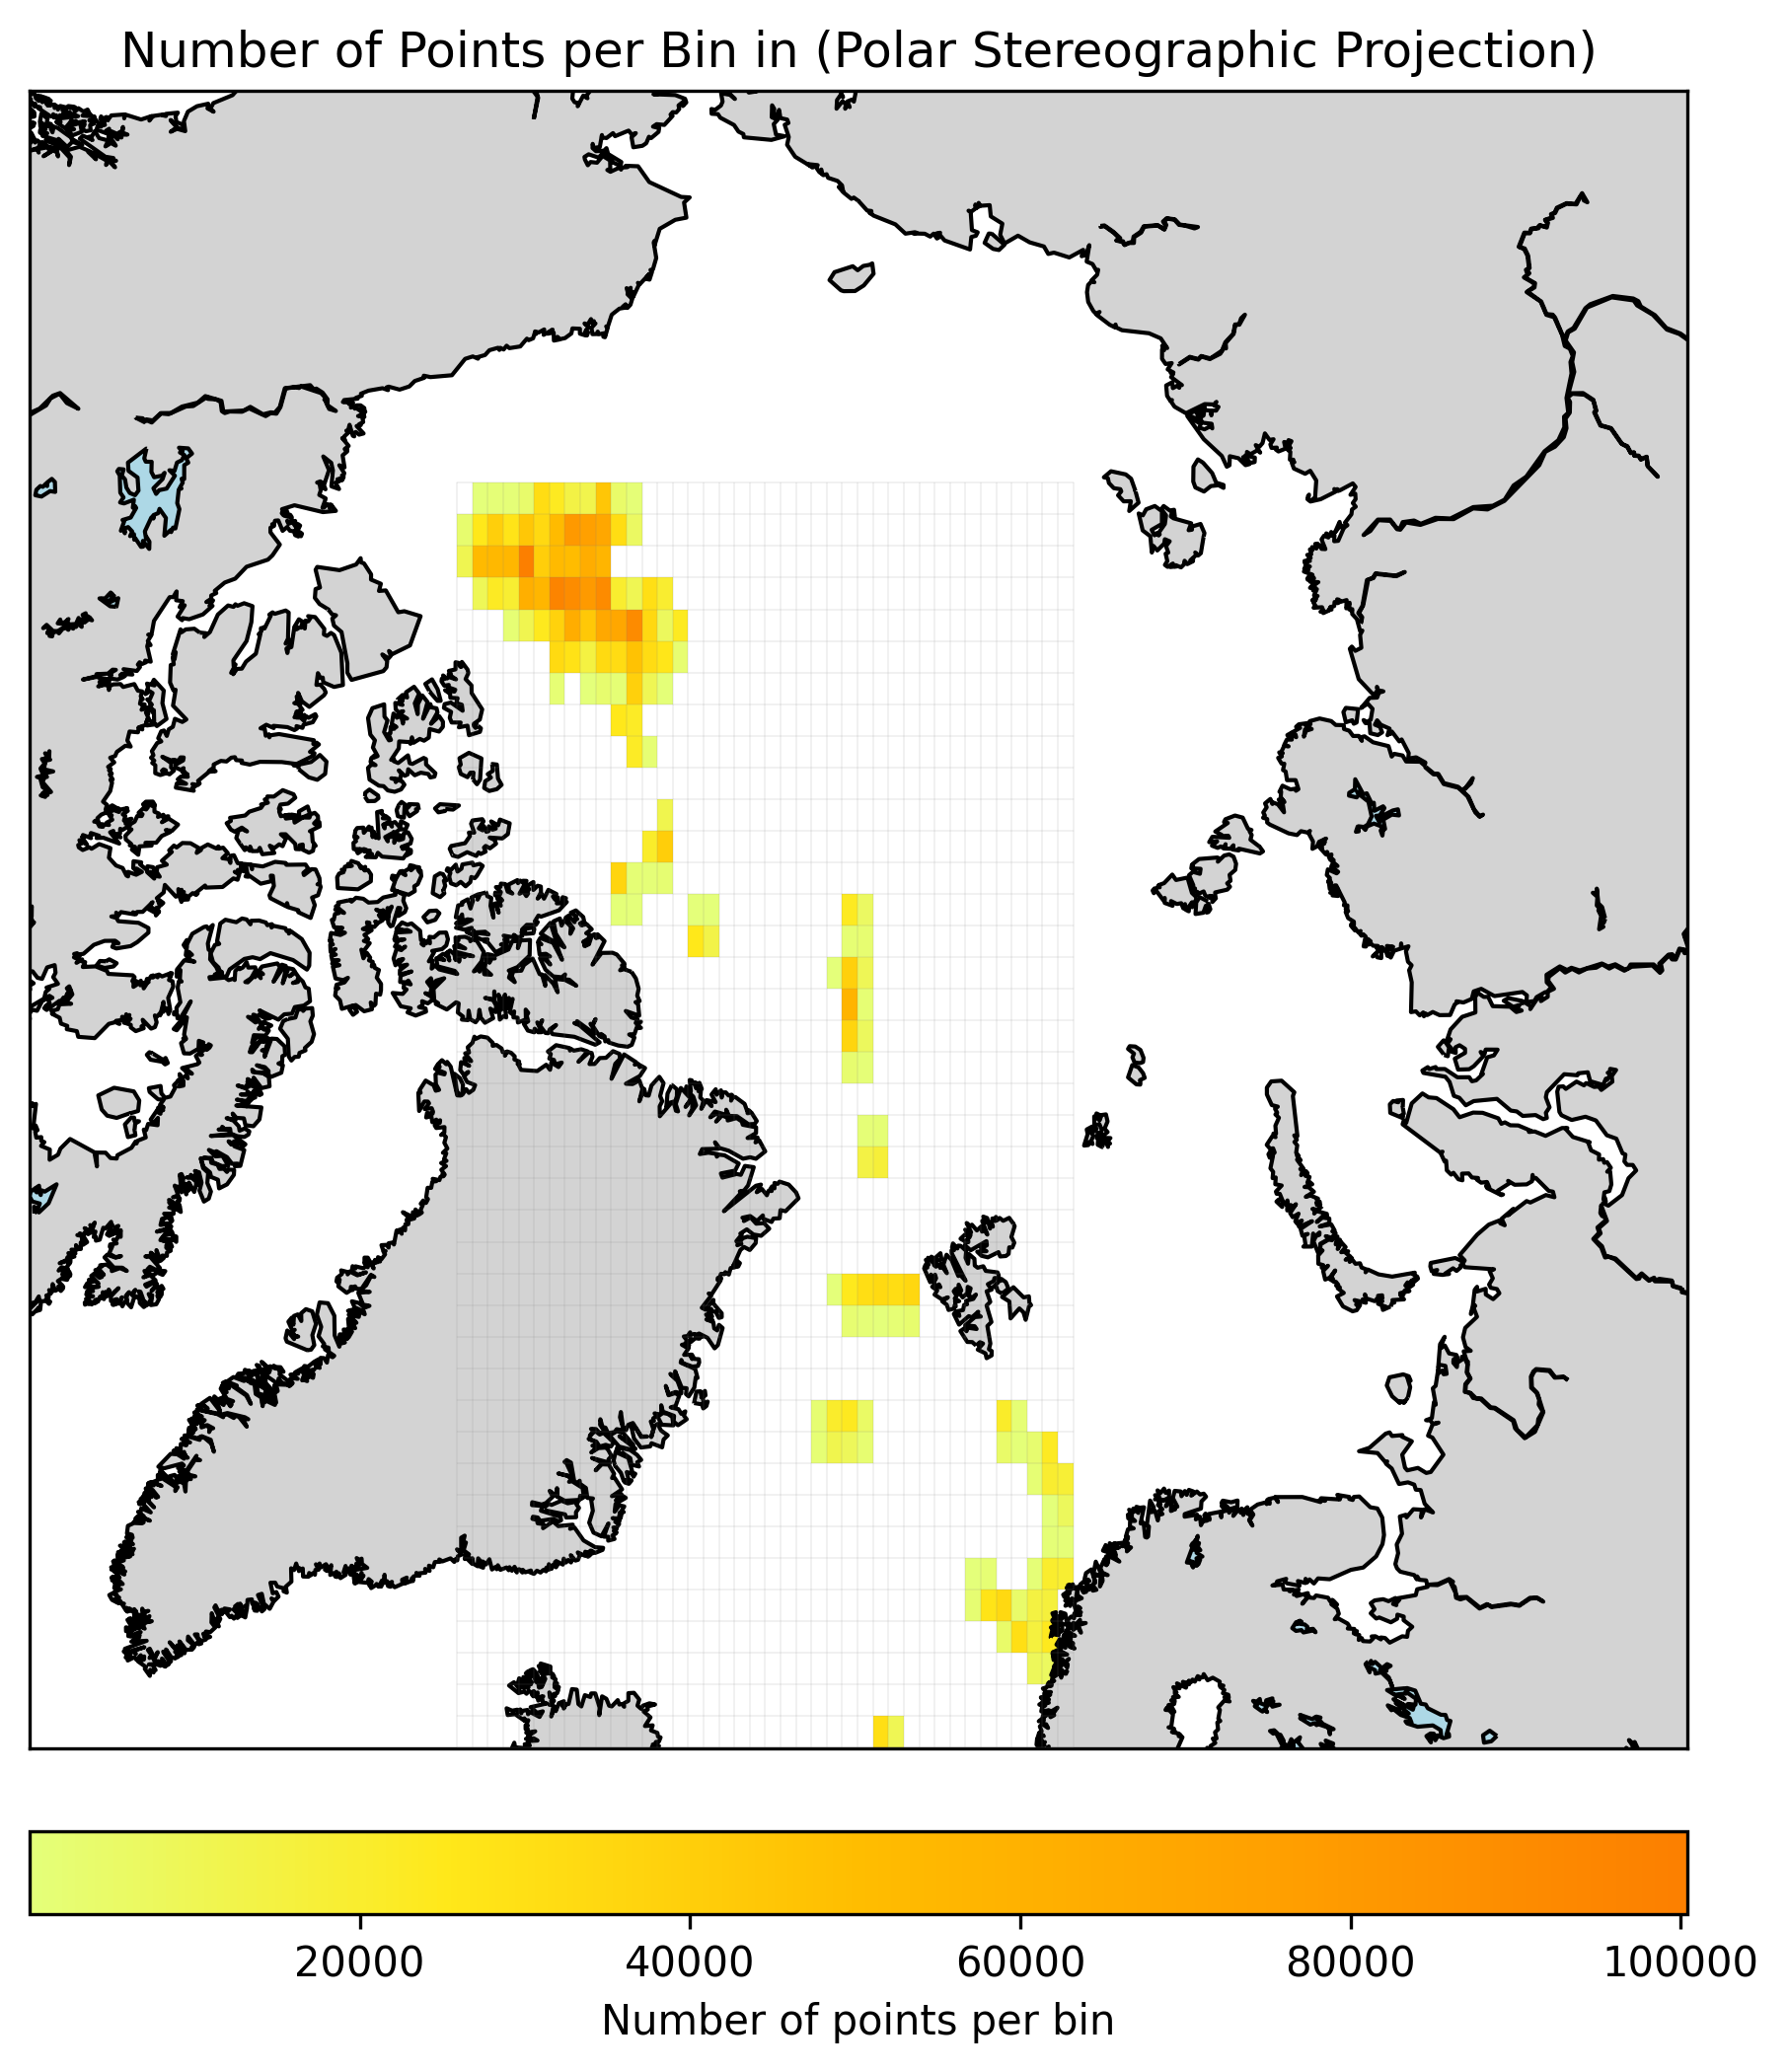

In [25]:
plot_heatmap_npts_xy(df_over_thresh, n_x_bins=40, n_y_bins=40, projection='npstere', projection_name='Polar Stereographic')

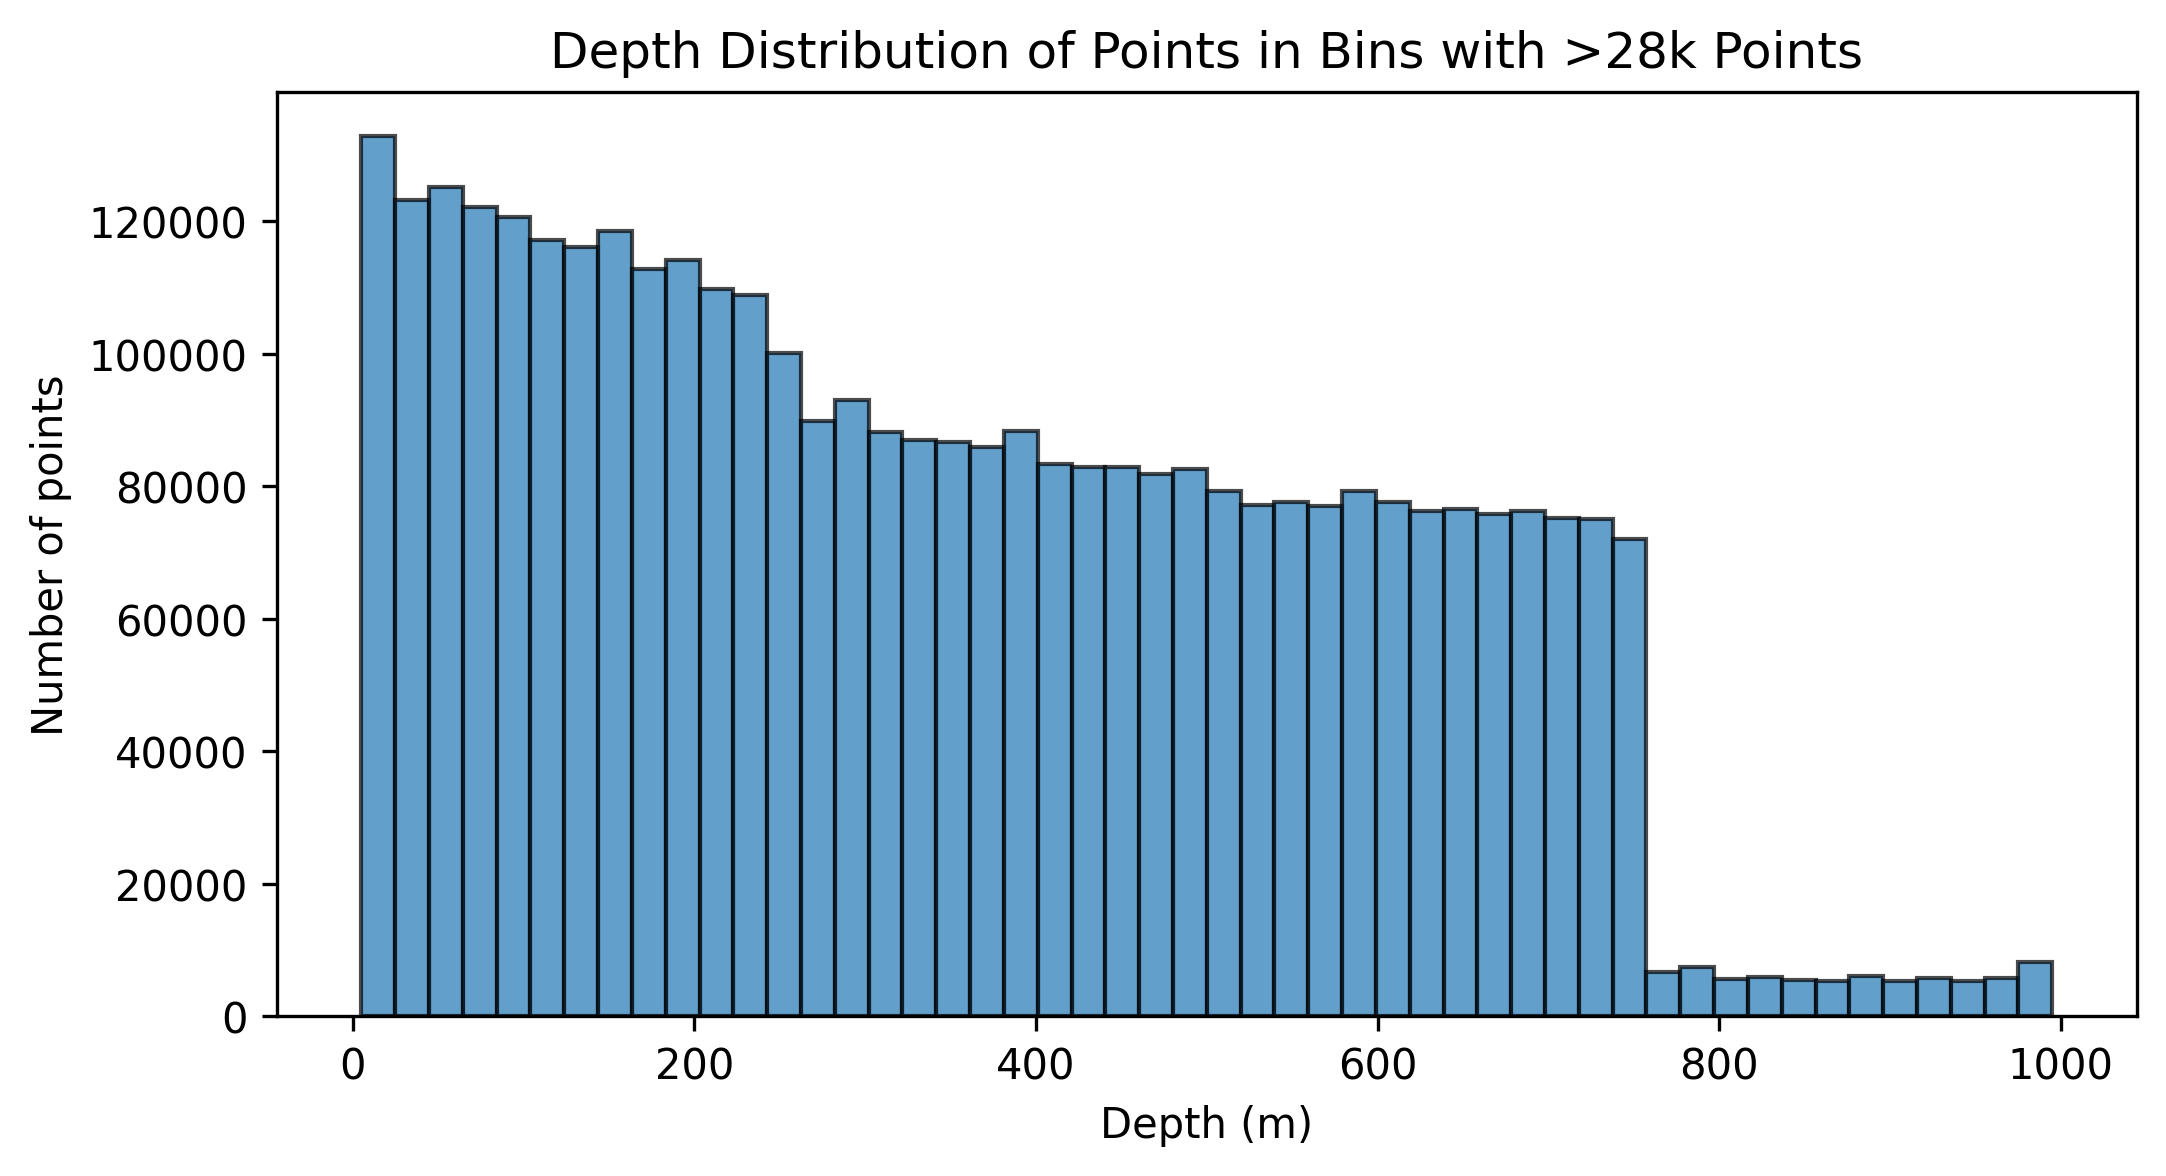

In [26]:
# depth histogram of points in bins over threshold
plt.figure(figsize=(8, 4), dpi=300)
plt.hist(df_over_thresh['Depth_[m]'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Depth (m)')
plt.ylabel('Number of points')
plt.title('Depth Distribution of Points in Bins with >28k Points')
plt.show()

In [27]:
def sample_cap_bins_xy(df, thresh, n_x_bins, n_y_bins):
    # Define projection and reproject lat/lon to x/y
    lat_min = df['Latitude_[deg_N]'].min()
    m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution='l')
    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges in projected space
    x_bins = np.linspace(x_vals.min(), x_vals.max(), n_x_bins + 1)
    y_bins = np.linspace(y_vals.min(), y_vals.max(), n_y_bins + 1)

    # Assign points to bins and clip edge cases
    x_idx = np.clip(np.digitize(x_vals, x_bins) - 1, 0, n_x_bins - 1)
    y_idx = np.clip(np.digitize(y_vals, y_bins) - 1, 0, n_y_bins - 1)

    # Build a dict mapping (xi, yi) -> list of original df indices
    # This is the single source of truth for bin membership
    from collections import defaultdict
    bin_members = defaultdict(list)
    for i in range(len(x_vals)):
        bin_members[(x_idx[i], y_idx[i])].append(i)

    # Sample each bin: cap at thresh if over, keep all if under
    sampled_indices = []
    for (xi, yi), members in bin_members.items():
        if len(members) > thresh:
            sampled_indices.extend(
                np.random.choice(members, size=thresh, replace=False)
            )
        else:
            sampled_indices.extend(members)

    df_sampled = df.iloc[sampled_indices].copy()
    return df_sampled

In [28]:
# Sample points in bins over threshold to cap at 28k points
df_sampled = sample_cap_bins_xy(df_ST, thresh=28000, n_x_bins=100, n_y_bins=100)

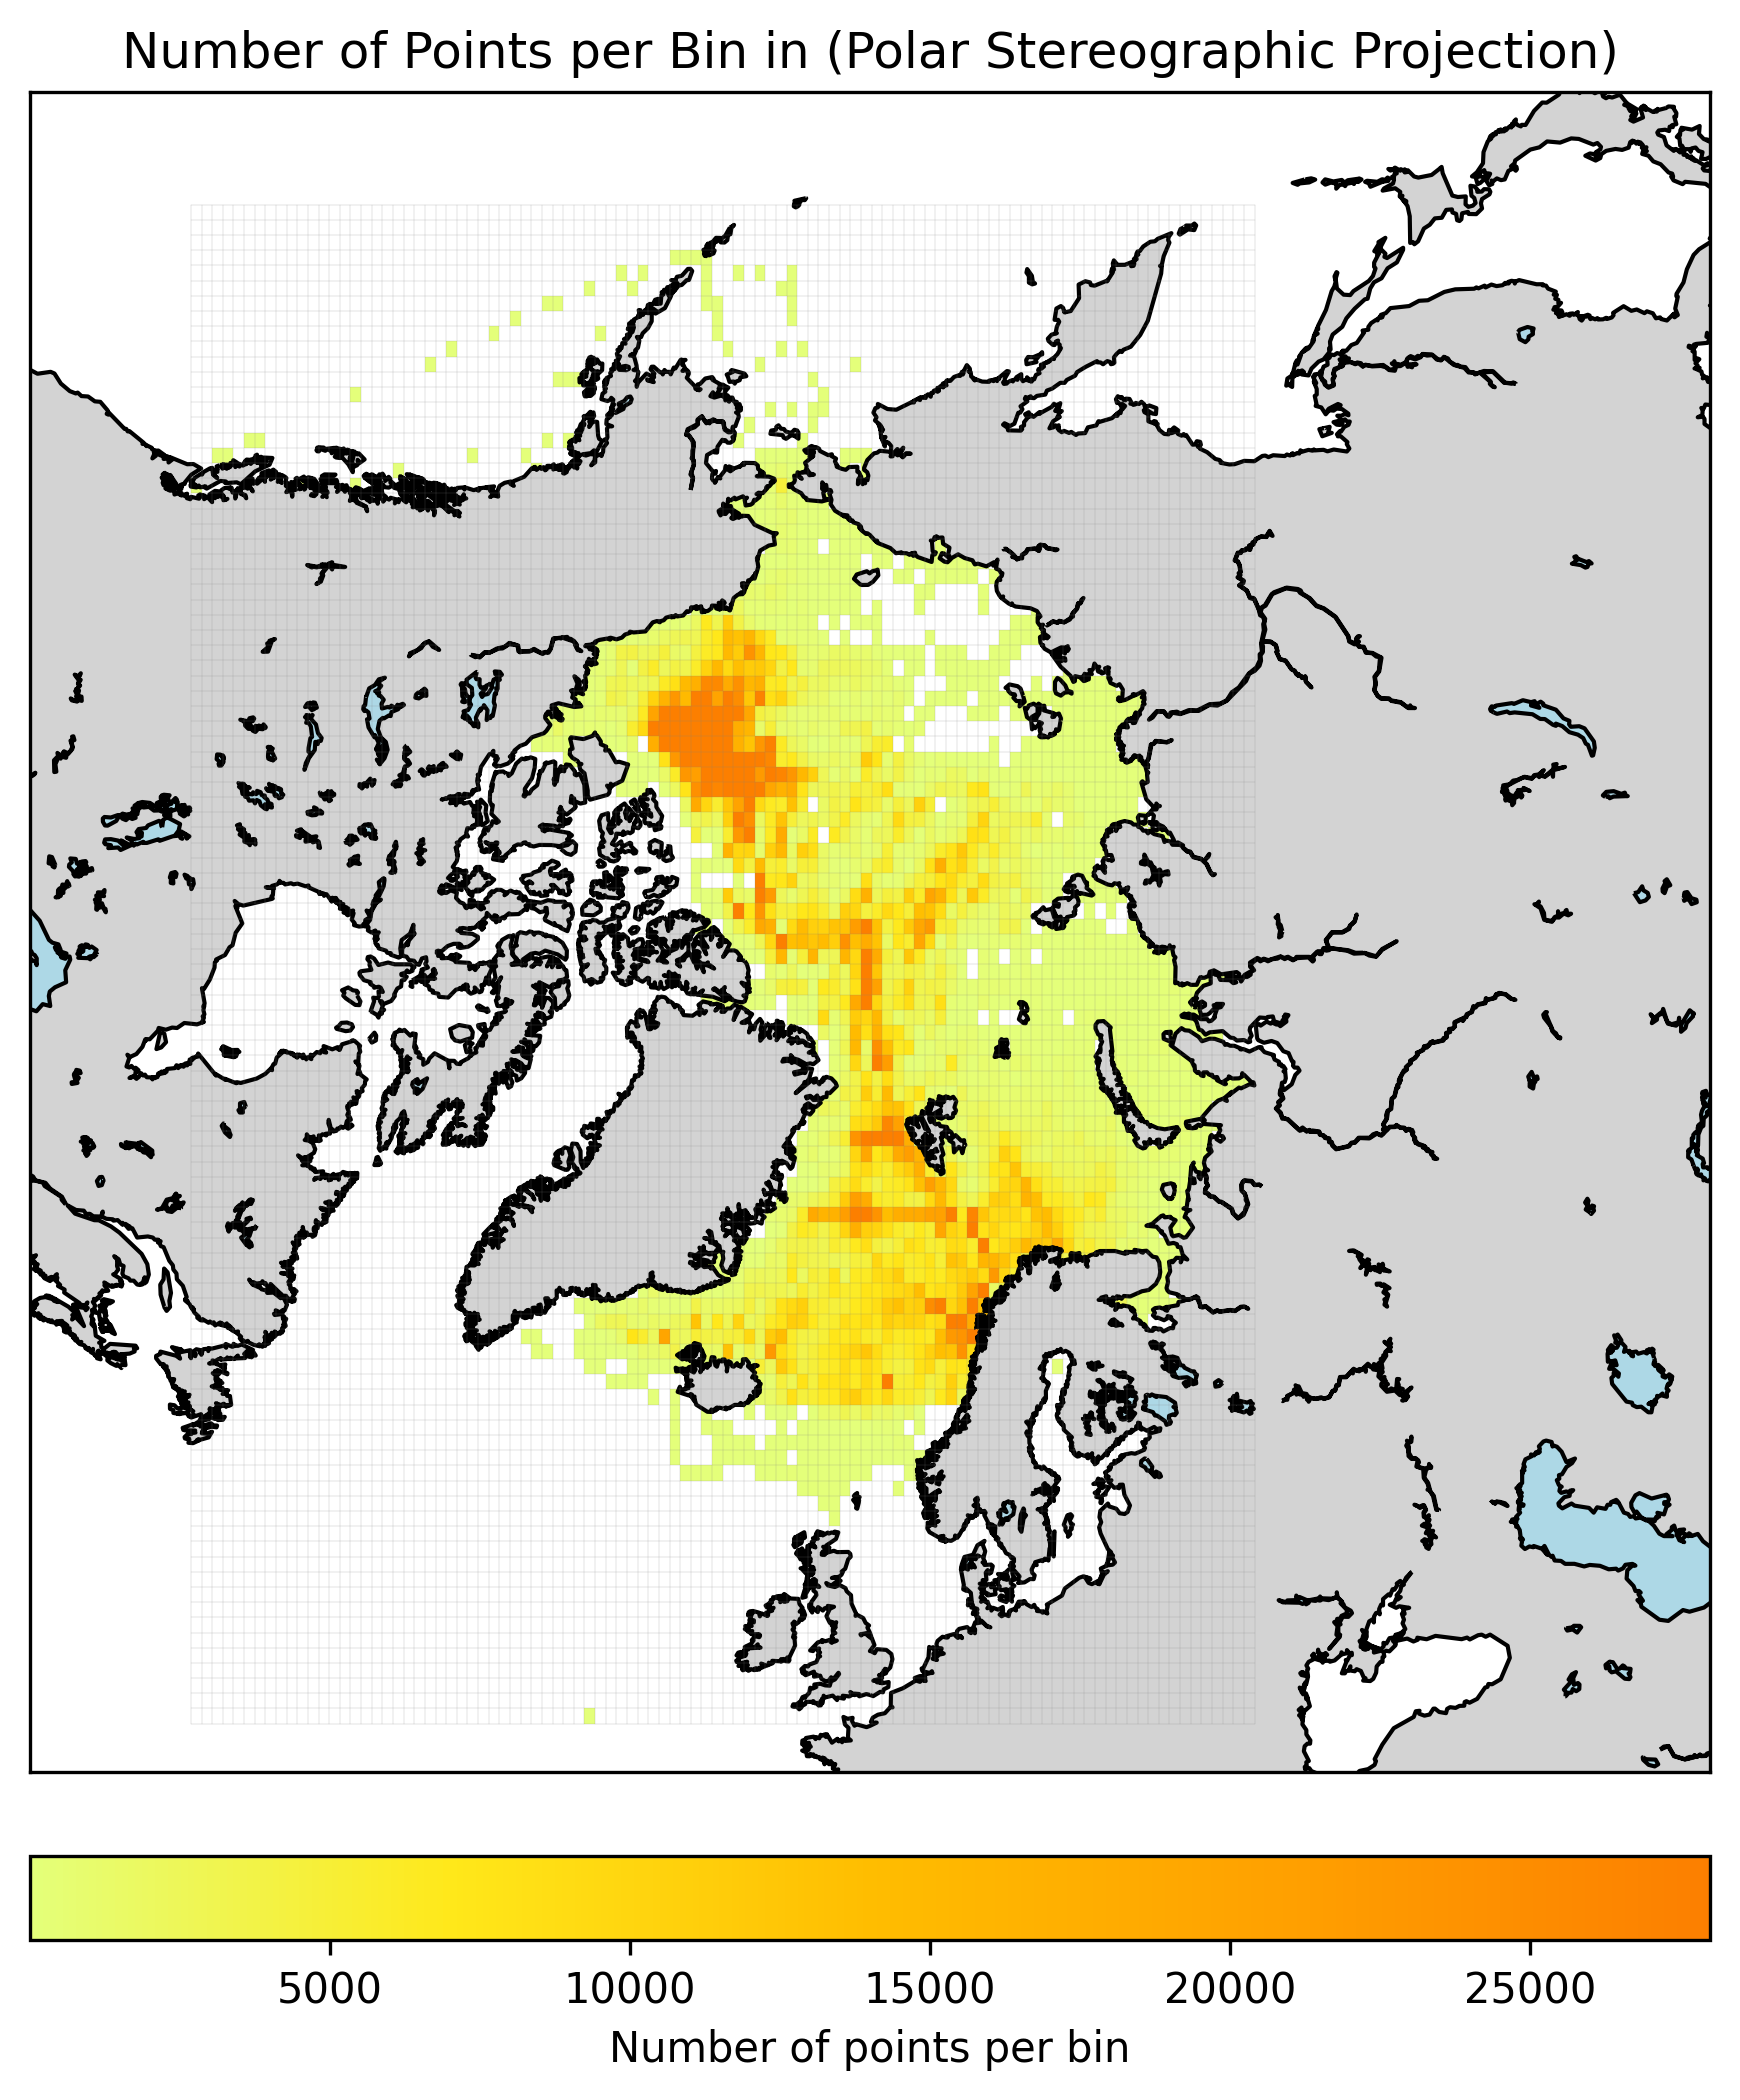

In [29]:
plot_heatmap_npts_xy(df_sampled, n_x_bins=100, n_y_bins=100, projection='npstere', projection_name='Polar Stereographic')

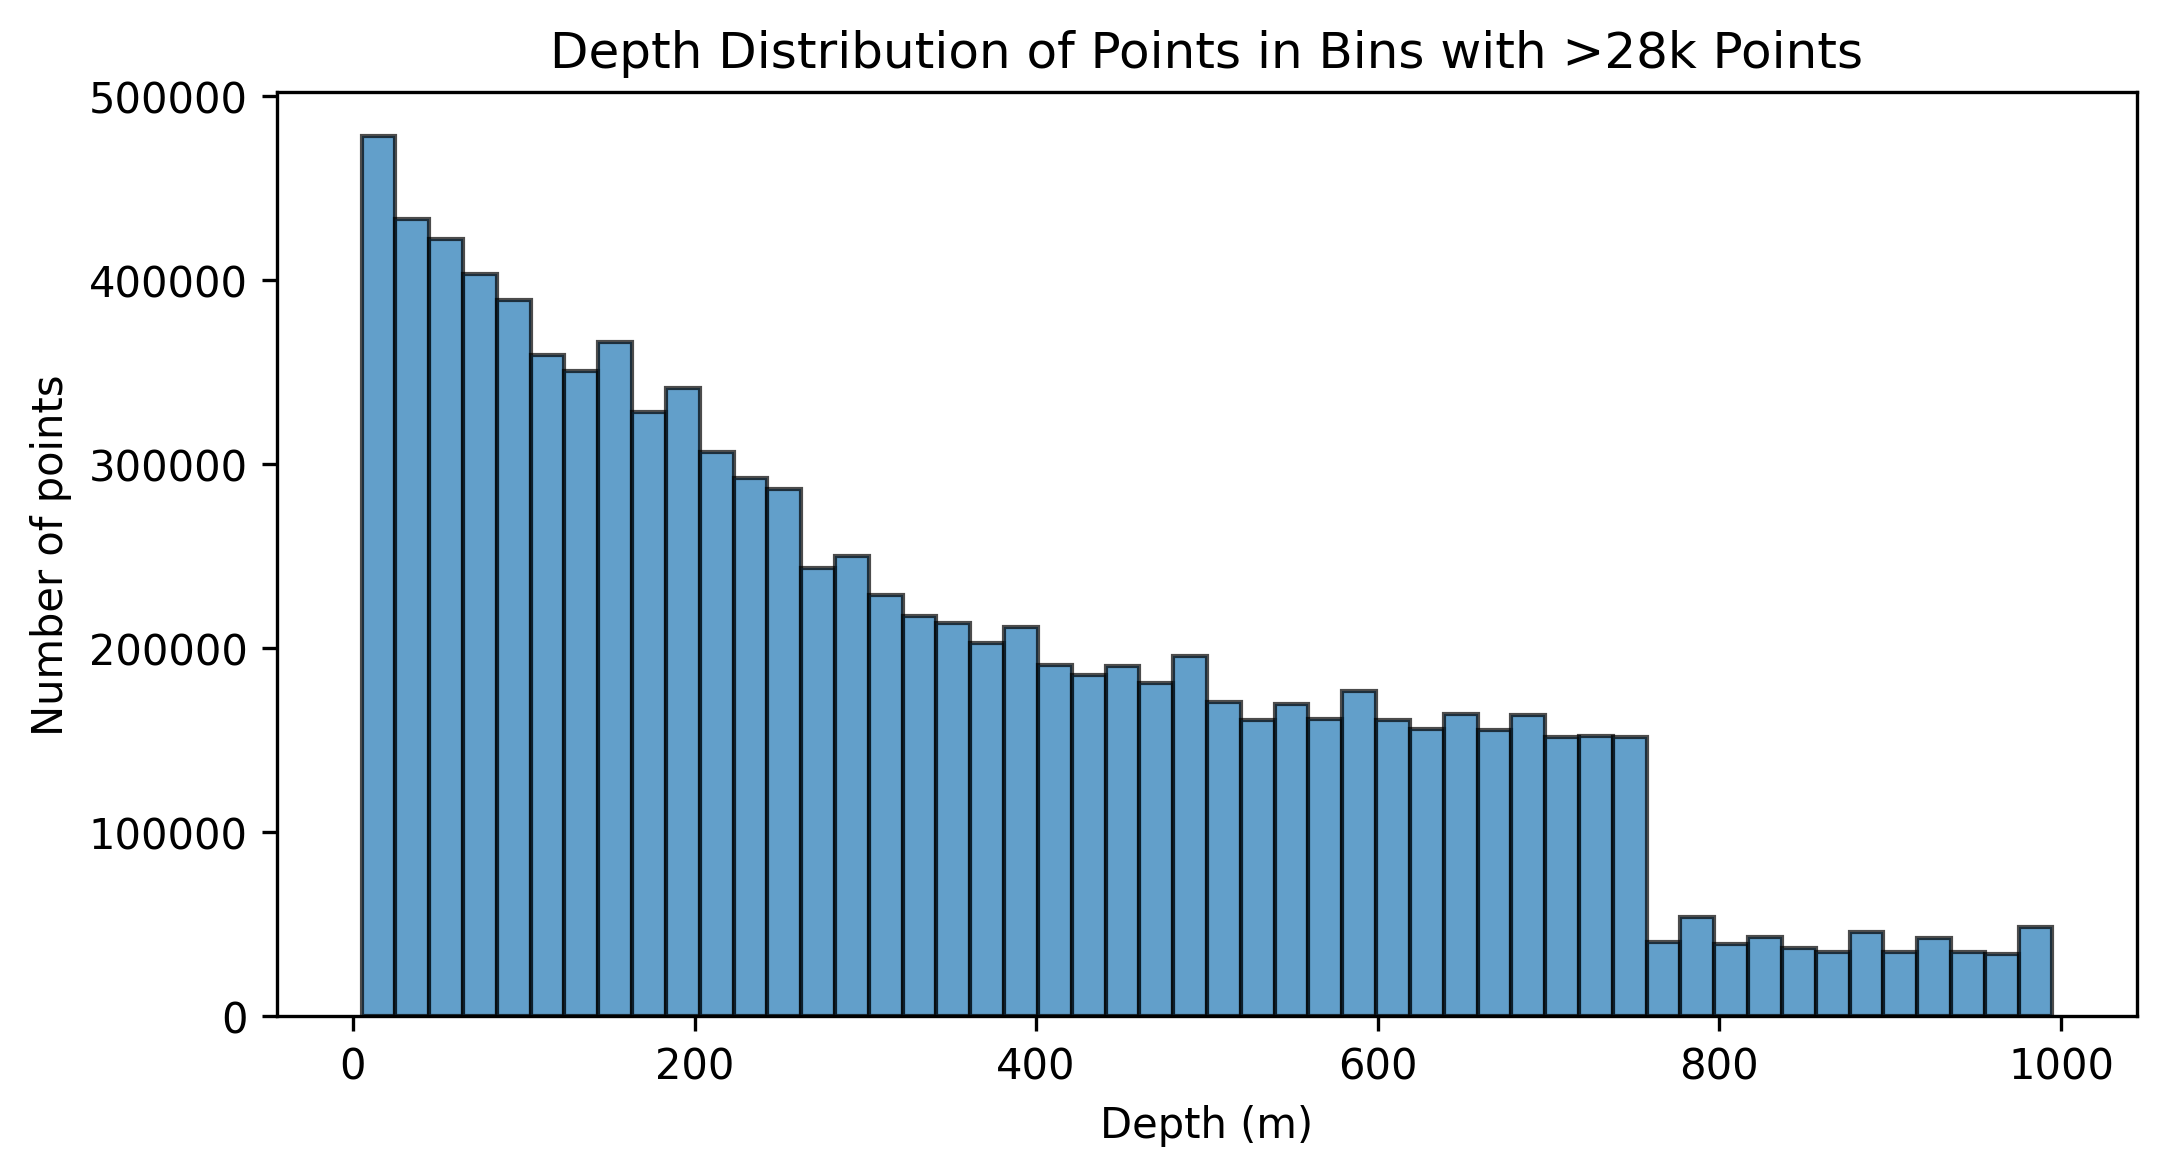

In [30]:
# depth histogram of sampled points
plt.figure(figsize=(8, 4), dpi=300)
plt.hist(df_sampled['Depth_[m]'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Depth (m)')
plt.ylabel('Number of points')
plt.title('Depth Distribution of Points in Bins with >28k Points')
plt.show()

In [31]:
profileNo_vs_xy_bins(df_sampled, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.99, projection='npstere')

# No Dimensionality Reduction GMM on sampled (polar stereographic projection)

In [32]:
import random
from sklearn.mixture import GaussianMixture
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm

In [33]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [37]:
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']

In [35]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
    gmm.fit(df_sampled[features])
    bic_scores.append(gmm.bic(df_sampled[features]))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

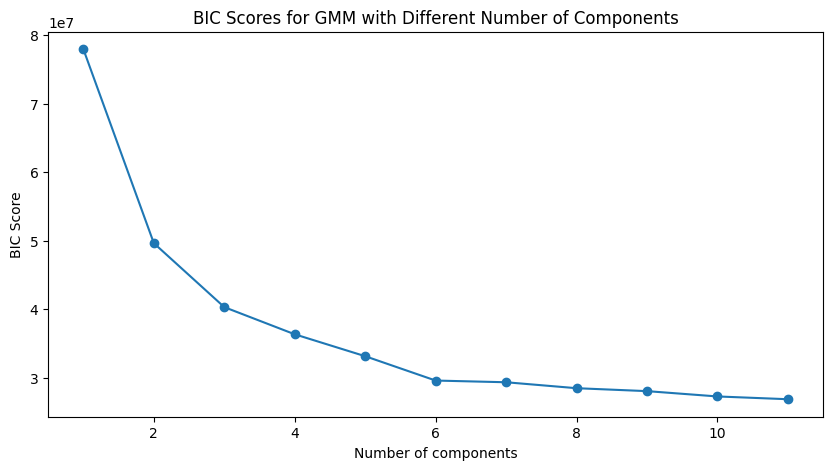

In [36]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [38]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 6

In [39]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [40]:
df_sampled['gmm_label'] = labels

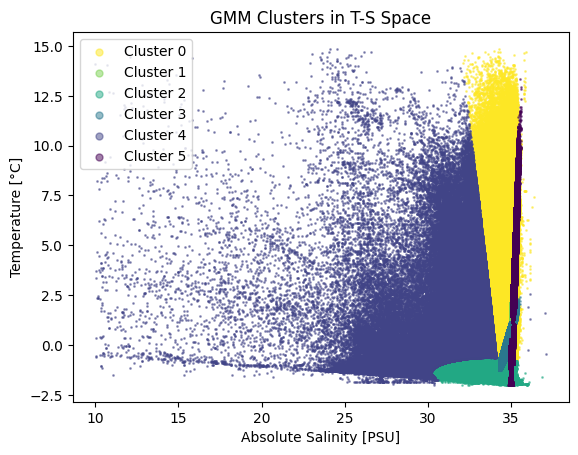

In [42]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_sampled['gmm_label'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space")
plt.legend(loc='upper left', markerscale=5)
plt.show()